# Chargement des modules

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import re as re

# Fonctions réutilisées

## Exercice 1

In [2]:
######################################### EXERCICE 1 #################################

def compute_shape_and_size(df: pd.DataFrame, df_name:str):
    print(f"Le fichier {df_name} comporte {df.shape[0]} lignes et {df.shape[1]} colonnes. \n"
          f"Le nombre d'élément est de {df.size}")


def compute_number_of_unique_entries(df: pd.DataFrame):
    unique_entries = (~df.duplicated()).values.sum()
    total_entries = df.shape[0]
    proportion_doublons = int((1 - (unique_entries / total_entries)) * 100)
    print(f"Le nombre d'entrée unique est de {unique_entries}, sur {total_entries} entrées au total. Soit { proportion_doublons}% de doublons")

def compute_prop_missing_values(df: pd.DataFrame, axe: int = 0):
    return  np.round((df.sum(axis=axe) / df.shape[axe]) * 100, 1)

def compute_and_plot_missing_values(df : pd.DataFrame):
            
    missing_values = df.isnull().astype("float")
    # Je veux calculer maintenant les proportions avant de modifier en place le dataframe.
    # Je trouve le fonctionnement suivant plus pratique : Je traite -> Je calcule les proportion -> Je dessine 
    prop_missing = compute_prop_missing_values(missing_values)

    missing_values = missing_values.replace(to_replace = 0, value= np.nan)

    ax = msno.bar(missing_values)
    fig = ax.get_figure()

# Missingno's 
    ax_proportion = fig.axes[0]
    ax_count = fig.axes[1]
    ax_dlabels = fig.axes[2]

# Show the proportion axis
    ax_proportion.yaxis.set_visible(True)
    ax_proportion.spines["right"].set_visible(True)
    ax_proportion.spines["left"].set_visible(True)
    ax_proportion.yaxis.set_ticks_position("left")
    ax_proportion.yaxis.set_label_position("left")
    ax_proportion.set_ylabel("Proportion", fontsize = 16)
    ax_proportion.grid(visible=True, color = "grey", which="major")
    

# Hide the count axis
    ax_count.yaxis.set_visible(False)
    ax_count.spines["right"].set_visible(False)
    ax_count.spines["left"].set_visible(False)
    ax_count.yaxis.set_ticks_position("left")
    ax_count.yaxis.set_label_position("left")
    
    ax_dlabels.set_xticks(ax.get_xticks())
    ax_dlabels.tick_params(rotation=0, top=True)
    ax.set_title("Missing values by column", fontsize = 20)
    
    fig.tight_layout()
    plt.show()

    return prop_missing


def get_columns_to_delete(ds: pd.Series, n : float = 75.0):
    mask = ds >= n
    return ds[mask].dropna().index 

def count_cat_occurences(df: pd.DataFrame):
    litteral_columns = list(df.select_dtypes("object").columns)

    occurences = {}
    for col in litteral_columns:
        occurences[col] = df[col].value_counts()

    return occurences


## Exercice 2

In [3]:
######################### EXERCICE 2 ######################


def compute_prop_values(df: pd.DataFrame):
    num_attributes = list(df.select_dtypes("float64").columns)
    prop_par_col = df[num_attributes].count(axis=0)/df.shape[0] *100 
    prop_par_idx = df[num_attributes].count(axis=1)/df.shape[1] *100
    df = df.loc[prop_par_idx > 50]
    nbr_valeurs_indicateurs = df.groupby("Indicator Name").count().sort_values(by="Country Name", ascending=False)
    
    return (prop_par_col, prop_par_idx, nbr_valeurs_indicateurs)


## Exercice 3

In [4]:
######################### EXERCICE 3 #######################

def draw_boxplot(df : pd.DataFrame):
    medianprops = {'color':"black"}
    meanprops = {'marker':'o',
                 'markeredgecolor':'black',
                 'markerfacecolor':'firebrick'}
    
    fig, axs = plt.subplots(3,1, figsize = (10,8))
    
    for idx, col in enumerate(df.columns):
        axe = axs[idx]
        axe.boxplot(df[col].dropna(),
                    orientation = "horizontal",
                    medianprops = medianprops,
                    patch_artist = True,
                    showfliers=True,
                    showmeans = True,
                    meanprops = meanprops,
                    tick_labels=[""])    
        axe.set_title(col)
    plt.tight_layout()
    plt.show()


def draw_displot(df: pd.DataFrame):

    fig, axs = plt.subplots(3,2, figsize= (12,8))
    
    for idx, col in enumerate(df.columns):    
        sns.histplot(ax = axs[idx, 0],
                    data = df,
                    x=col,    
                    kde=True
                   )
        sns.ecdfplot(ax = axs[idx, 1],
                    data = df,
                    x=col,    
                   )
    fig.suptitle('Hist vs ECDF')
    plt.tight_layout()
    plt.show()


def weighted_average(group: pd.DataFrame):
    return (
        (group["Value"]*group["Weight"]).sum() 
        / group["Weight"].sum() 
    )

def pareto_frontier(df):
    df = df.dropna()
    values = df.to_numpy()
    pareto = np.ones(len(df), dtype=bool)

    for i in range(len(df)):
        dominated = np.all(values >= values[i], axis = 1) & \
                    np.any(values > values[i], axis = 1)
    
        if dominated.any():
            pareto[i] = False 
            
    return df[pareto]


def find_robust_countries(df : pd.DataFrame,
                          weights_combination : list[tuple[float, ...]],
                          top_n : int=5 ):
    ranks = [] 
    for weights in weights_combination:
        scores = df.multiply(weights).sum(axis=1)
        country_ranks = scores.rank(method = "min", ascending = False )
        
        ranks.append(country_ranks)
        
    ranks = pd.concat(ranks, axis=1)
    
    mean_ranks = round(ranks.mean(axis=1), 1)
    median_ranks = round(ranks.median(axis=1), 1)

    top_n_frequency = (ranks <= top_n).mean(axis=1)
    
    results = pd.DataFrame({
        "%_top_n": round(top_n_frequency*100, 1),
        "rang_moyen": mean_ranks,
        "rang_median": median_ranks
    })
    return results.sort_values(["%_top_n", "rang_moyen"],
                               ascending = [False, True])

# EXERCICE 1

## Etape 1 - Chargement des fichiers dans le Notebook

In [5]:
def is_csv(filepath: str):
    ext = os.path.splitext(filepath)[1].lower()
    return ext == ".csv"

cwd = os.path.join(os.getcwd(), "data") # cwd est un objet DirEntry, on peut accéder au path via l'attribut

dfs_container = {}  # stockera les dfs chargés

for element in os.scandir(cwd):
    if element.is_file() and is_csv(element.path):
        *_, file_name, _ = re.split( r'[/.]', element.path)
        df = pd.read_csv(element.path)
        dfs_container[file_name] = df

In [6]:
display(dfs_container["EdStatsData"])

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886925,Zimbabwe,ZWE,"Youth illiterate population, 15-24 years, male...",UIS.LP.AG15T24.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886926,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, b...",SE.ADT.1524.LT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886927,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886928,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Explication : Je n'avais pas envie d'écrire 5 read_csv("csv_file_path").

Les DataFrames sont chargés et mis dans une liste. La longueur de la liste est de 5, j'ai donc bien tous les fichiers demandés.


## Etape 2 - A la recherche d'information

Objectifs : 

    - Comprendre l'organisation de chaque DataFrame (head, info, shape)
    
    - Identifier les liens éventuels entre chaque (colonne identique à travers les DF)
    
    - Tirer le maximum d'information (unique, value_counts, describe?, duplicated) 
    

### Analyse préliminaire
En analyse préliminaire, nous pouvons regarder comment chaque DataFrame est organisé.

In [7]:
for _, (key, df) in enumerate(dfs_container.items()):
    compute_shape_and_size(df, key)
    print("\n")

Le fichier EdStatsCountry comporte 241 lignes et 32 colonnes. 
Le nombre d'élément est de 7712


Le fichier EdStatsData comporte 886930 lignes et 70 colonnes. 
Le nombre d'élément est de 62085100


Le fichier EdStatsSeries comporte 3665 lignes et 21 colonnes. 
Le nombre d'élément est de 76965


Le fichier EdStatsCountry-Series comporte 613 lignes et 4 colonnes. 
Le nombre d'élément est de 2452


Le fichier EdStatsFootNote comporte 643638 lignes et 5 colonnes. 
Le nombre d'élément est de 3218190




Etant donné les différences notables d'organisation et de nombre d'éléments entre chaque DataFrame, nous allons les regarder un par un pour comprendre ce qu'ils représentent.

### Premier dataset

In [8]:
country_df = dfs_container["EdStatsCountry"]
country_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 32 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Country Code                                       241 non-null    str    
 1   Short Name                                         241 non-null    str    
 2   Table Name                                         241 non-null    str    
 3   Long Name                                          241 non-null    str    
 4   2-alpha code                                       238 non-null    str    
 5   Currency Unit                                      215 non-null    str    
 6   Special Notes                                      145 non-null    str    
 7   Region                                             214 non-null    str    
 8   Income Group                                       214 non-null    str    
 9   WB-2 code            

In [9]:
country_df.describe()

,National accounts reference year,Latest industrial data,Latest trade data,Unnamed: 31
count,32.00000,107.000000,185.000000,0.0
mean,2001.53125,2008.102804,2010.994595,NaN
std,5.24856,2.616834,2.569675,NaN
min,1987.00000,2000.000000,1995.000000,NaN
25%,1996.75000,2007.500000,2011.000000,NaN
50%,2002.00000,2009.000000,2012.000000,NaN
75%,2005.00000,2010.000000,2012.000000,NaN
max,2012.00000,2010.000000,2012.000000,NaN


En première analyse, nous identifions 241 lignes faisant référence à des pays. Les attributs de ces pays sont au nombre de 32, avec 28 de type littéral (object -> str), et 4 de type numérique (float64). 

Néanmoins, plusieurs observations sont possibles à partir des méthodes .head() et .infos() : 

- Les attributs de format numérique semblent correspondre à des années où certaines actions étatiques ont été effectuées pour la dernière fois. C'est le cas pour les attributs Latest trade data, Latest industrial data, National accounts reference year.
- La dernière colonne (Unnamed: 31), bien qu'au format numérique, est vide (0 non-null valeurs).
- Le nombre de données diffère grandement entre pays, avec par exemple 238 entrées pour l'attribut 2-alpha code, et 32 pour le National accounts reference year.

De ces informations, je peux à présent regarder le nombre de doublons, s'ils existent, supprimer la colonne inutilisable, et calculer la proportion de valeurs manquantes par colonnes.


In [10]:
compute_number_of_unique_entries(country_df)

Le nombre d'entrée unique est de 241, sur 241 entrées au total. Soit 0% de doublons


Avec la première information, nous pouvons voir que toutes les entrées du premier attribut sont uniques. Etant donné que cet attribut correspond à la désignation d'un pays, chaque entrée correspond bien à un pays distinct.


Supprimons à présent la colonne inutilisable

In [11]:
country_df.drop(columns={"Unnamed: 31"}, inplace=True)

Calculons maintenant la proportion de valeurs manquantes dans chaque attribut

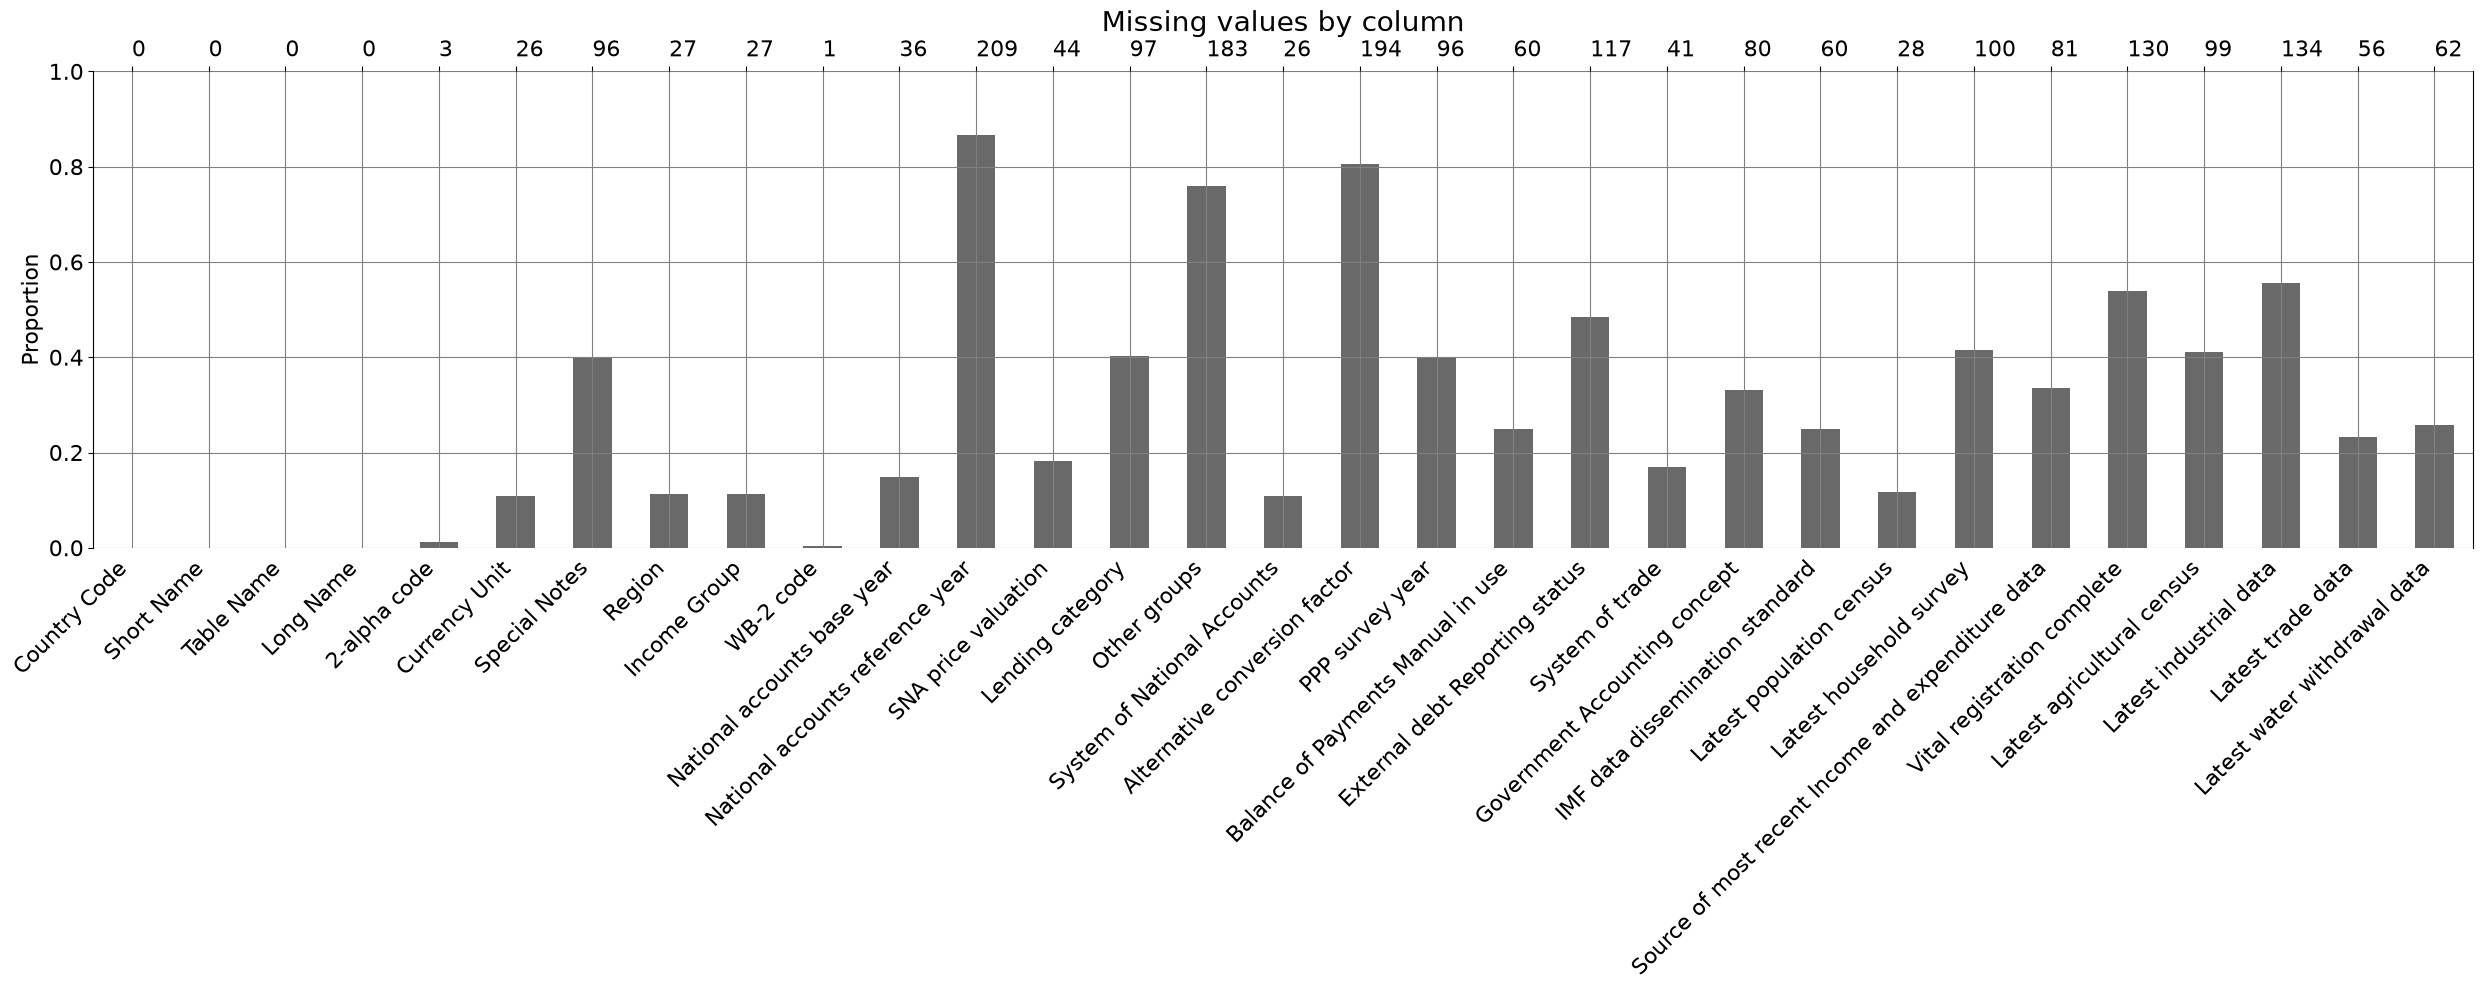

In [12]:
prop_missing = compute_and_plot_missing_values(country_df)

In [13]:
display(prop_missing)

Country Code                                          0.0
Short Name                                            0.0
Table Name                                            0.0
Long Name                                             0.0
2-alpha code                                          1.2
Currency Unit                                        10.8
Special Notes                                        39.8
Region                                               11.2
Income Group                                         11.2
WB-2 code                                             0.4
National accounts base year                          14.9
National accounts reference year                     86.7
SNA price valuation                                  18.3
Lending category                                     40.2
Other groups                                         75.9
System of National Accounts                          10.8
Alternative conversion factor                        80.5
PPP survey yea

**NOTE :** Pour aller plus loin dans la gestion des colonnes inutilisables, nous pouvons appliquer par exemple une condition. 
Ex : si une colonne a plus de n% de valeurs manquantes, alors on la supprime.
La case ci-dessous réalise cette tâche avec n = 75.

**Regarder comment gérer les valeurs manquantes**

In [14]:
columns_to_delete = get_columns_to_delete(prop_missing, 75)

country_df.drop(columns = columns_to_delete, inplace = True)


**NOTE IMPORTANTE POUR MOI-MÊME :** Pour supprimer des colonnes, il faut passer par un objet "hashable" - qui utilise une table de hash pour stocker les valeurs (dict, set, frozen set). Donc, utiliser une liste ou tuple ne fonctionne pas. *MAIS* les objets Index des DataFrame sont des objets hashables. 

Les statistiques descriptives de chaque colonne de type numérique ayant déjà été montrées plus haut, regardons le nombre d'occurence de chaque valeur des attributs "littéraux".

Pour cela, je vais d'abord sélectionner les attributs littéraux, puis un à un calculer l'occurrence des valeurs via value_counts. Et pour finir, les stocker dans un dictionnaire avec le nom des attributs comme index.
Je pourrais directement le faire sur le dataframe filtré en entier, mais je trouve le résultat peu lisible (cf case juste en dessous)

%% **QUESTION :** l'entièreté du dataFrame est prise en compte lors du df.value_counts() ? Est-ce qu'une occurrence est comptée comme double quand TOUTES les attributs sont identiques sur deux entrées ?    

In [15]:
#first_df.select_dtypes("object").value_counts()

In [16]:
occurences_country = count_cat_occurences(country_df)

# Ex : 
display(occurences_country["Government Accounting concept"])

/tmp/ipykernel_209864/782226003.py:66: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  litteral_columns = list(df.select_dtypes("object").columns)


Government Accounting concept
Consolidated central government    95
Budgetary central government       66
Name: count, dtype: int64

### Deuxième dataset

In [17]:
data_df = dfs_container["EdStatsData"]

data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 886930 entries, 0 to 886929
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    886930 non-null  str    
 1   Country Code    886930 non-null  str    
 2   Indicator Name  886930 non-null  str    
 3   Indicator Code  886930 non-null  str    
 4   1970            72288 non-null   float64
 5   1971            35537 non-null   float64
 6   1972            35619 non-null   float64
 7   1973            35545 non-null   float64
 8   1974            35730 non-null   float64
 9   1975            87306 non-null   float64
 10  1976            37483 non-null   float64
 11  1977            37574 non-null   float64
 12  1978            37576 non-null   float64
 13  1979            36809 non-null   float64
 14  1980            89122 non-null   float64
 15  1981            38777 non-null   float64
 16  1982            37511 non-null   float64
 17  1983            38460

In [18]:
data_df.describe()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
count,7.228800e+04,3.553700e+04,3.561900e+04,3.554500e+04,3.573000e+04,8.730600e+04,3.748300e+04,3.757400e+04,3.757600e+04,3.680900e+04,...,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,0.0
mean,1.974772e+09,4.253638e+09,4.592365e+09,5.105006e+09,5.401493e+09,2.314288e+09,5.731808e+09,6.124437e+09,6.671489e+09,7.436724e+09,...,7.224868e+02,7.271290e+02,7.283779e+02,7.266484e+02,7.228327e+02,7.176899e+02,7.113072e+02,7.034274e+02,6.940296e+02,NaN
std,1.211687e+11,1.804814e+11,1.914083e+11,2.059170e+11,2.112150e+11,1.375059e+11,2.215546e+11,2.325489e+11,2.473986e+11,2.660957e+11,...,2.215845e+04,2.287990e+04,2.352338e+04,2.408149e+04,2.455897e+04,2.496587e+04,2.530183e+04,2.556069e+04,2.574189e+04,NaN
min,-1.435564e+00,-1.594625e+00,-3.056522e+00,-4.032582e+00,-4.213563e+00,-3.658569e+00,-2.950945e+00,-3.174870e+00,-3.558749e+00,-2.973612e+00,...,-1.630000e+00,-1.440000e+00,-1.260000e+00,-1.090000e+00,-9.200000e-01,-7.800000e-01,-6.500000e-01,-5.500000e-01,-4.500000e-01,NaN
25%,8.900000e-01,8.853210e+00,9.240920e+00,9.595200e+00,9.861595e+00,1.400000e+00,9.312615e+00,9.519913e+00,1.000000e+01,1.000000e+01,...,3.000000e-02,3.000000e-02,2.000000e-02,2.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,NaN
50%,6.317724e+00,6.316240e+01,6.655139e+01,6.969595e+01,7.087760e+01,9.677420e+00,7.101590e+01,7.133326e+01,7.290512e+01,7.510173e+01,...,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.200000e-01,NaN
75%,6.251250e+01,5.655200e+04,5.863650e+04,6.202900e+04,6.383675e+04,7.854163e+01,5.682800e+04,5.739175e+04,5.940425e+04,6.411500e+04,...,7.505000e+00,7.500000e+00,7.300000e+00,7.100000e+00,6.722500e+00,6.080000e+00,5.462500e+00,4.680000e+00,4.032500e+00,NaN
max,1.903929e+13,1.986457e+13,2.100916e+13,2.238367e+13,2.282991e+13,2.300634e+13,2.424128e+13,2.521383e+13,2.622101e+13,2.730873e+13,...,2.951569e+06,3.070879e+06,3.169711e+06,3.246239e+06,3.301586e+06,3.337871e+06,3.354746e+06,3.351887e+06,3.330484e+06,NaN


A première vue, le DataFrame représente l'évolution de différents indicateurs à travers les ans (1970 -> 2100). 
On peut alors supposer qu'une partie des attributs est une donnée mesurée, et l'autre est projetée.

Concernant le type des attributs, seuls 4 sont littéraux, le reste étant numériques. Cela fait sens, les 2 premiers sont le code et le nom de pays, les deux suivants sont les indicateurs et leurs codes.

Comme tous les indicateurs sont mélangés, il est difficile de faire des observations quant aux statistiques descriptives sur le dataset initial. On peut néanmoins regarder si d'éventuels doublons sont disséminés parmi les données.

In [19]:
compute_number_of_unique_entries(data_df)

Le nombre d'entrée unique est de 886930, sur 886930 entrées au total. Soit 0% de doublons


A priori, aucun doublon. On peut déjà supprimer la dernière colonne (Unnamed: 69), qui ne comprend aucune donnée. Suite à cela, on calculera la proportion de données manquantes par attribut

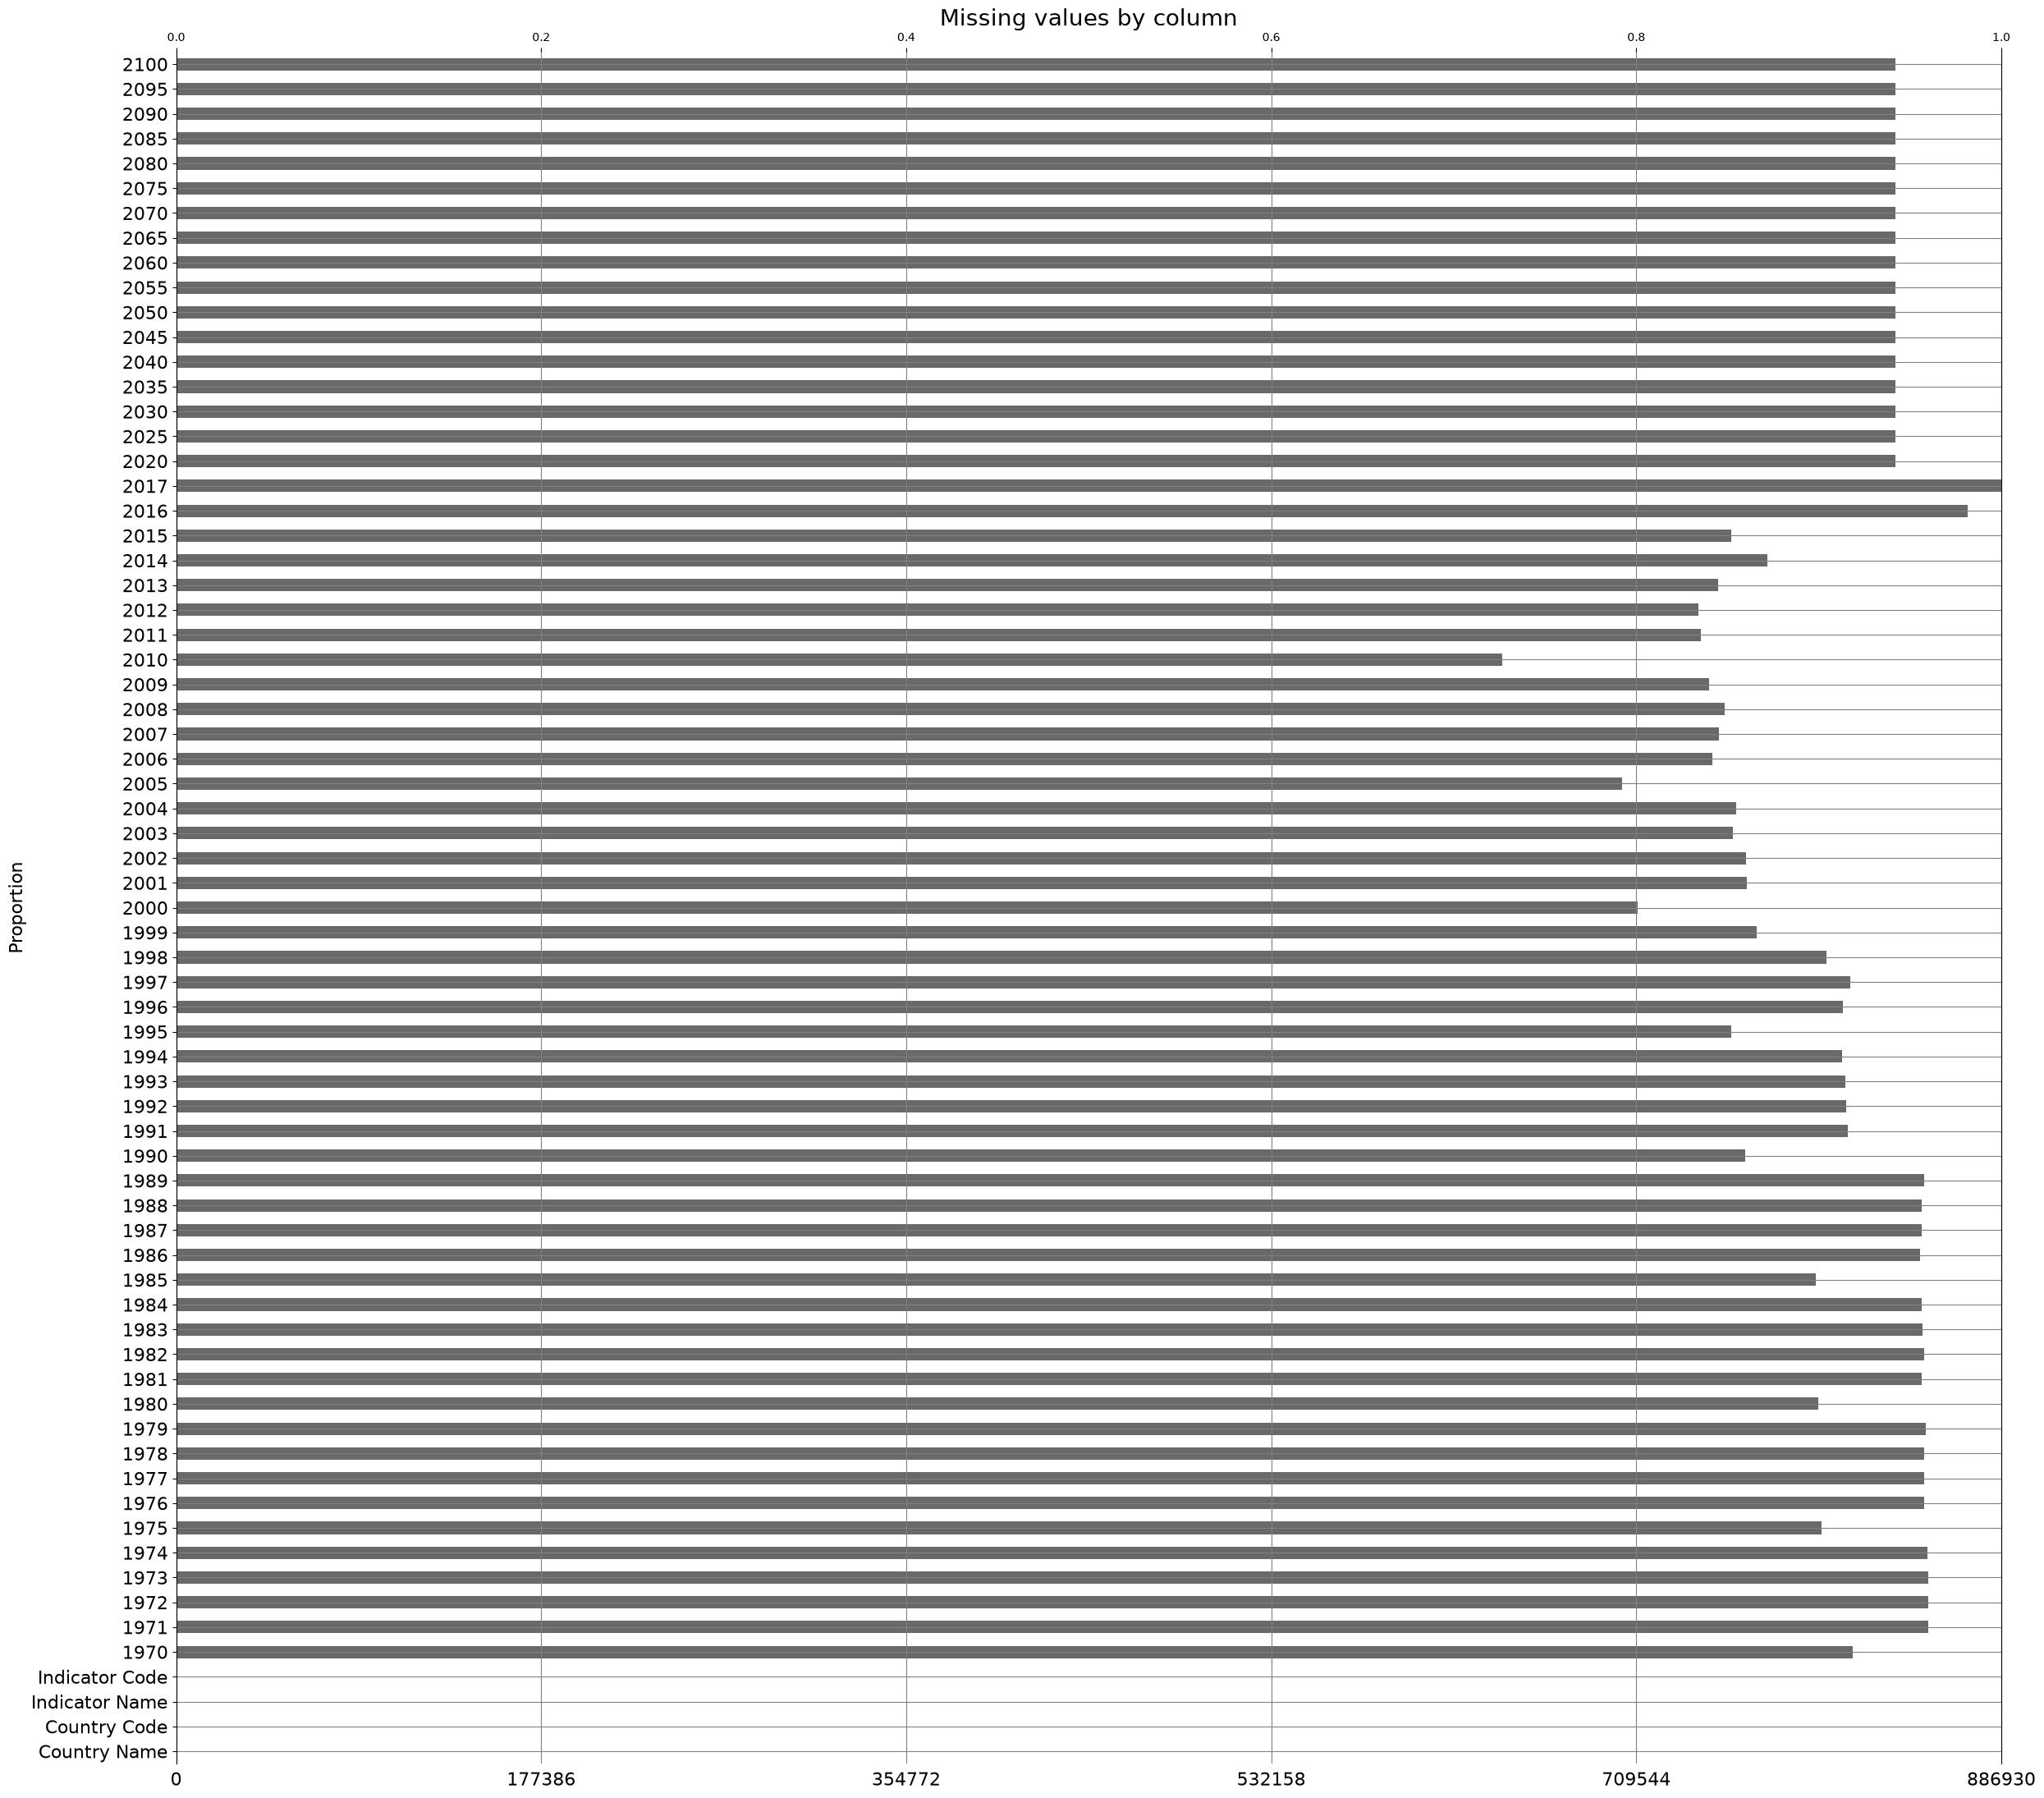

In [20]:
data_df.drop(columns = "Unnamed: 69", inplace= True)

prop_missing = compute_and_plot_missing_values(data_df)

In [21]:
display(prop_missing)

Country Name       0.0
Country Code       0.0
Indicator Name     0.0
Indicator Code     0.0
1970              91.8
                  ... 
2080              94.2
2085              94.2
2090              94.2
2095              94.2
2100              94.2
Length: 69, dtype: float64

In [22]:
columns_to_delete = get_columns_to_delete(prop_missing, 75)

display(data_df.drop(columns = columns_to_delete))

,Country Name,Country Code,Indicator Name,Indicator Code,2010
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,85.211998
...,...,...,...,...,...
886925,Zimbabwe,ZWE,"Youth illiterate population, 15-24 years, male...",UIS.LP.AG15T24.M,NaN
886926,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, b...",SE.ADT.1524.LT.ZS,NaN
886927,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,NaN
886928,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,NaN


Cela ne nous avance pas beaucoup. Si l'on suit le raisonnement évoqué avec le premier dataset, la quasi-totalité des attributs numériques sont à supprimer par manque d'information. Tout supprimer enlèverait beaucoup d'informations et potentiellement de l'information utile.

Un autre raisonnement serait de vérifier non pas les attributs ayant beaucoup de valeurs manquantes, mais plutôt les entrées.
En effet, si certains indicateurs n'ont que très peu d'entrées concernées, alors ceux-là sont réellement fautifs du manque d'information.

Pour cela, on peut grouper le DataFrame par indicateur.

In [23]:
#num_attributes = list(second_df.select_dtypes("float64").columns)
#test=second_df.groupby(["Indicator Name"])[num_attributes].count()
#test



In [24]:
###### A COMPLETER

#nbr_values = np.array(test.replace(0,np.nan).count())
#nbr_max_values = len(list(second_df.columns))

#proportion_missing = np.round((1 - (nbr_values / np.max(nbr_values)))*100, decimals = 1)
#proportion_missing


#prop_missing_per_indicator = zip(indicator, proportion_missing)
#prop_missing_per_column = pd.DataFrame(prop_missing_per_column, columns = ["attributes", "missing_values"]).set_index("attributes")
#display(prop_missing_per_column)

#nbr_values

Suite à cela, nous pouvons calculer le nombre d'occurrences de chaque colonne catégorielle selon :

In [25]:
occurences_data = count_cat_occurences(data_df)

# Ex : 
occurences_data["Country Name"]

/tmp/ipykernel_209864/782226003.py:66: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  litteral_columns = list(df.select_dtypes("object").columns)


Country Name
Arab World                                     3665
East Asia & Pacific                            3665
East Asia & Pacific (excluding high income)    3665
Euro area                                      3665
Europe & Central Asia                          3665
                                               ... 
Virgin Islands (U.S.)                          3665
West Bank and Gaza                             3665
Yemen, Rep.                                    3665
Zambia                                         3665
Zimbabwe                                       3665
Name: count, Length: 242, dtype: int64

### Troisième dataset

In [26]:
series_df = dfs_container["EdStatsSeries"]

display(series_df.head(3))

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
series_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3665 entries, 0 to 3664
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Series Code                          3665 non-null   str    
 1   Topic                                3665 non-null   str    
 2   Indicator Name                       3665 non-null   str    
 3   Short definition                     2156 non-null   str    
 4   Long definition                      3665 non-null   str    
 5   Unit of measure                      0 non-null      float64
 6   Periodicity                          99 non-null     str    
 7   Base Period                          314 non-null    str    
 8   Other notes                          552 non-null    str    
 9   Aggregation method                   47 non-null     str    
 10  Limitations and exceptions           14 non-null     str    
 11  Notes from original source           0 no

In [28]:
series_df.describe()

,Unit of measure,Notes from original source,Other web links,Related indicators,License Type,Unnamed: 20
count,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN


Selon df.info(), nous avons 6 attributs numériques et 15 attributs catégoriels. De plus, les attributs numériques sont exempts de données, étant remplis de NaN. Ce faisant, nous pouvons les supprimer.

In [29]:
num_col = list(series_df.select_dtypes("float64"))
series_df.drop(columns=num_col,inplace=True)
series_df

,Series Code,Topic,Indicator Name,Short definition,Long definition,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,General comments,Source,Statistical concept and methodology,Development relevance,Related source links
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3660,UIS.XUNIT.USCONST.3.FSGOV,Expenditures,Government expenditure per upper secondary stu...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN
3661,UIS.XUNIT.USCONST.4.FSGOV,Expenditures,Government expenditure per post-secondary non-...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN
3662,UIS.XUNIT.USCONST.56.FSGOV,Expenditures,Government expenditure per tertiary student (c...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN
3663,XGDP.23.FSGOV.FDINSTADM.FFD,Expenditures,Government expenditure in secondary institutio...,"Total general (local, regional and central) go...","Total general (local, regional and central) go...",NaN,NaN,Secondary,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN


La proportion de données manquantes par colonne est de : 

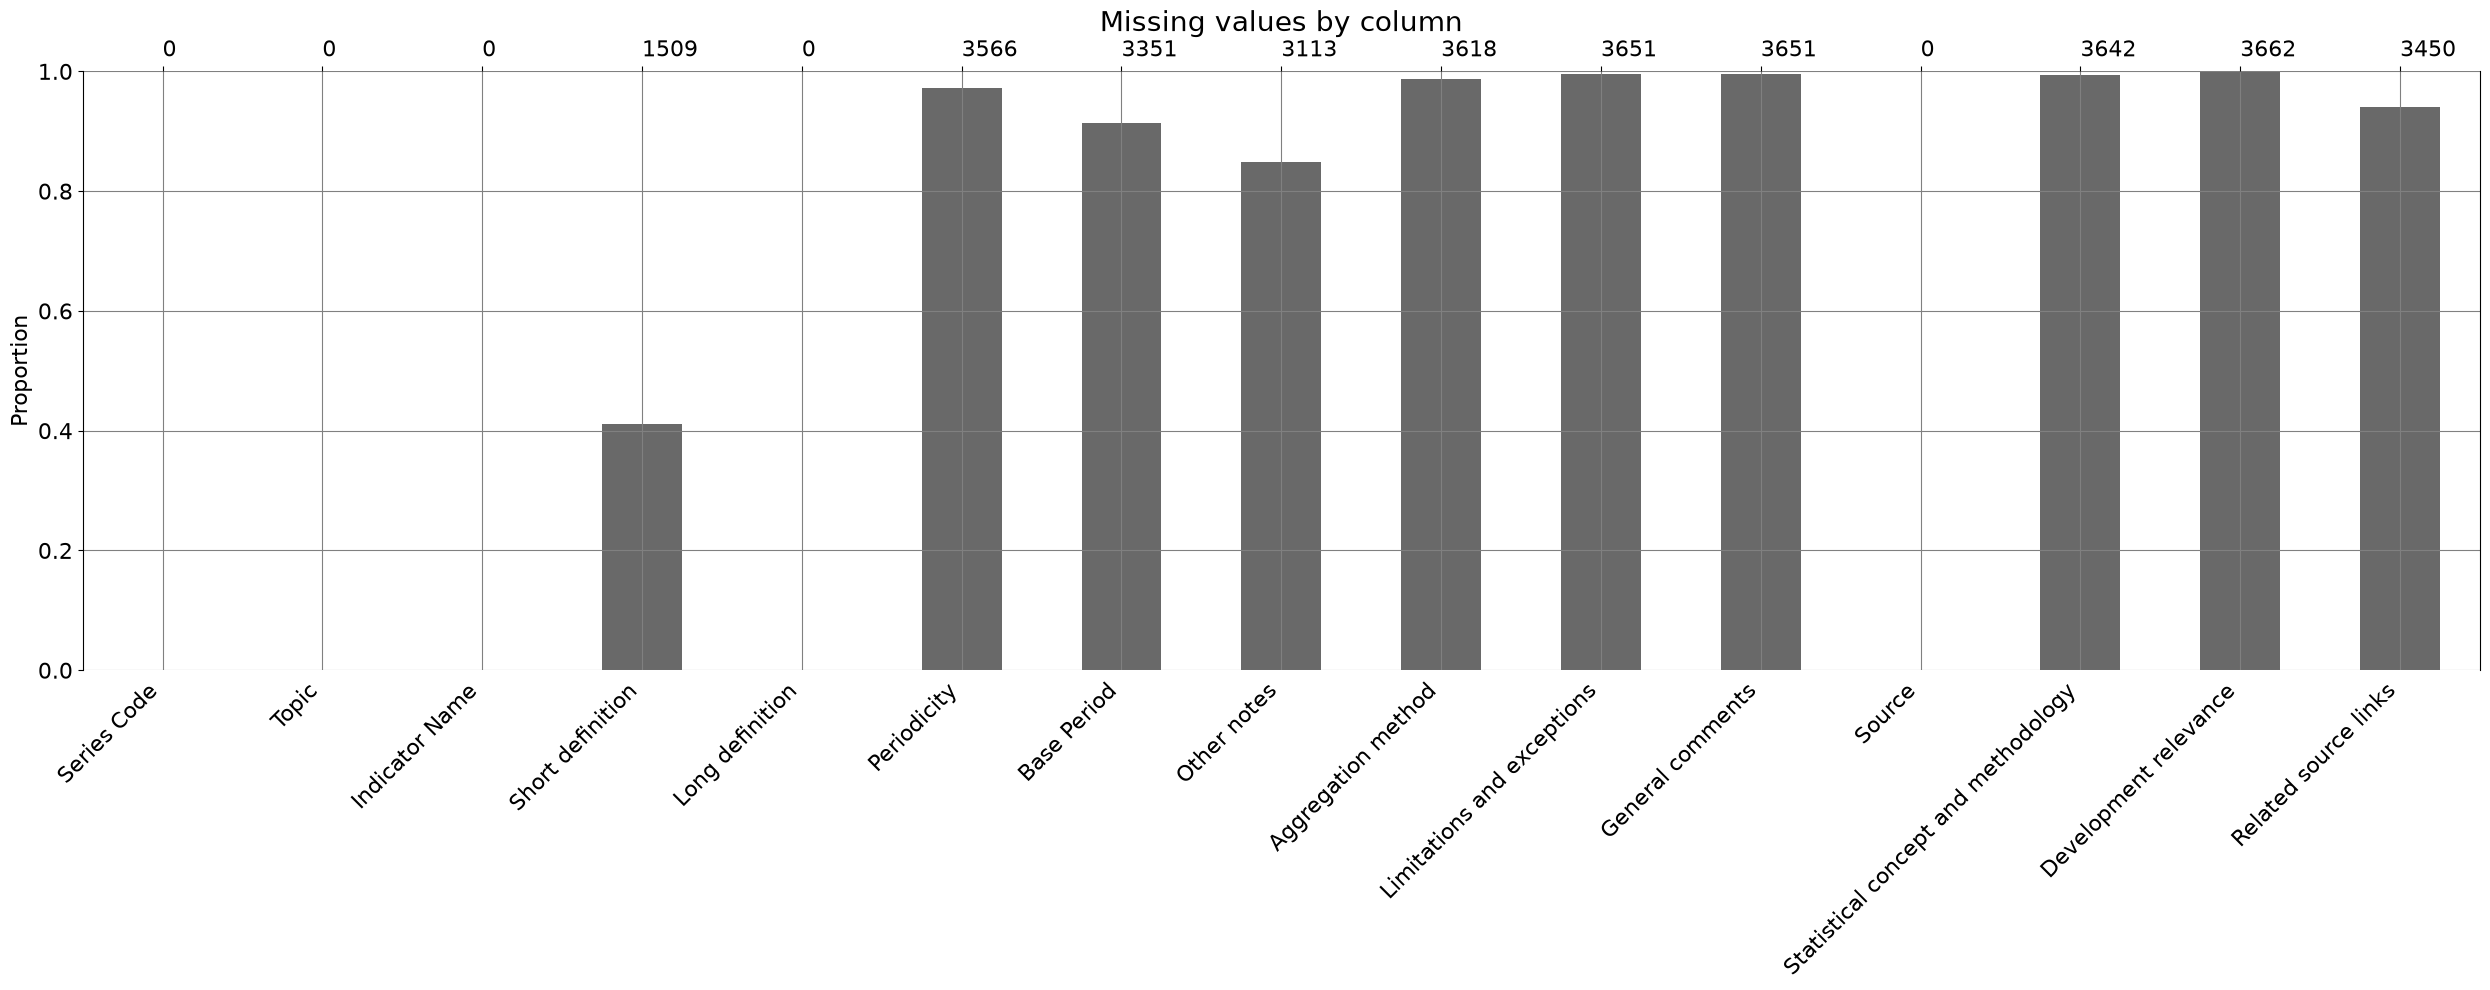

In [30]:
prop_missing = compute_and_plot_missing_values(series_df)

In [31]:
display(prop_missing)

Series Code                             0.0
Topic                                   0.0
Indicator Name                          0.0
Short definition                       41.2
Long definition                         0.0
Periodicity                            97.3
Base Period                            91.4
Other notes                            84.9
Aggregation method                     98.7
Limitations and exceptions             99.6
General comments                       99.6
Source                                  0.0
Statistical concept and methodology    99.4
Development relevance                  99.9
Related source links                   94.1
dtype: float64

Étant donné que la majorité des attributs ayant des données manquantes ont un taux > 80 %, je fais le choix de supprimer celles remplissant la condition. J'y ajoute également l'attribut "Short definition", car il est redondant avec "Long definition"

In [32]:
columns_to_delete = get_columns_to_delete(prop_missing, 75)

series_df.drop(columns = columns_to_delete, inplace = True)

Enfin, je calcule le nombre d'occurrences par colonne catégorielle : 

In [33]:
val_occurences_series = count_cat_occurences(series_df)

display(val_occurences_series["Topic"])

/tmp/ipykernel_209864/782226003.py:66: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  litteral_columns = list(df.select_dtypes("object").columns)


Topic
Learning Outcomes                                                                               1046
Attainment                                                                                       733
Education Equality                                                                               426
Secondary                                                                                        256
Primary                                                                                          248
Population                                                                                       213
Tertiary                                                                                         158
Teachers                                                                                         137
Expenditures                                                                                      93
Engaging the Private Sector (SABER)                                                  

### Quatrième dataset

In [34]:
country_series_df = dfs_container["EdStatsCountry-Series"]

display(country_series_df.head(3))

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...,NaN


In [35]:
country_series_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 613 entries, 0 to 612
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CountryCode  613 non-null    str    
 1   SeriesCode   613 non-null    str    
 2   DESCRIPTION  613 non-null    str    
 3   Unnamed: 3   0 non-null      float64
dtypes: float64(1), str(3)
memory usage: 19.3 KB


In [36]:
country_series_df.describe()

,Unnamed: 3
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


Le quatrième dataset possède 3 attributs catégoriels et un numérique. Le seul attribut numérique est inutilisable, il est donc à supprimer.
Avec ceci, on peut regarder le nombre de doublons éventuels

In [37]:
country_series_df.drop(columns="Unnamed: 3", inplace=True)

In [38]:
compute_number_of_unique_entries(country_series_df)

Le nombre d'entrée unique est de 613, sur 613 entrées au total. Soit 0% de doublons


Finalement, le nombre d'occurrences de chaque valeur dans chaque attribut catégoriciel : 

In [39]:
val_occurences_country_series = count_cat_occurences(country_series_df)

display(val_occurences_country_series["DESCRIPTION"])

/tmp/ipykernel_209864/782226003.py:66: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  litteral_columns = list(df.select_dtypes("object").columns)


DESCRIPTION
Data sources : United Nations World Population Prospects                                              154
Data sources: United Nations World Population Prospects                                               137
Estimates are based on regression.                                                                     84
Data sources : Eurostat                                                                                54
Derived using ratio of age group from WPP and World Bank population.                                   24
                                                                                                     ... 
Data sources: U.S. Census Bureau, United Nations Population and Vital Statistics Report                 1
Data sources: General Statistics Office of Vietnam                                                      1
Data sources : General Statistics Office of Vietnam                                                     1
Data sources : World Bank's Kosovo

### Cinquième dataset

In [40]:
footnote_df = dfs_container["EdStatsFootNote"]

display(footnote_df.head(3))

,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,NaN


In [41]:
footnote_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 643638 entries, 0 to 643637
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CountryCode  643638 non-null  str    
 1   SeriesCode   643638 non-null  str    
 2   Year         643638 non-null  str    
 3   DESCRIPTION  643638 non-null  str    
 4   Unnamed: 4   0 non-null       float64
dtypes: float64(1), str(4)
memory usage: 24.6 MB


In [42]:
footnote_df.describe()

,Unnamed: 4
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


Le cinquième dataset est assez semblable au quatrième. Un seul attribut numérique inutilisable, et 3 catégoriels. On reprend donc les mêmes opérations ci-dessous

In [43]:
footnote_df.drop(columns="Unnamed: 4", inplace=True)

In [44]:
compute_number_of_unique_entries(footnote_df)

Le nombre d'entrée unique est de 643638, sur 643638 entrées au total. Soit 0% de doublons


In [45]:
val_occurences_footnote = count_cat_occurences(footnote_df)

display(val_occurences_footnote["DESCRIPTION"])

/tmp/ipykernel_209864/782226003.py:66: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  litteral_columns = list(df.select_dtypes("object").columns)


DESCRIPTION
Country Data                                      191188
UNESCO Institute for Statistics (UIS) estimate    171527
Estimated                                         117155
UIS Estimation                                     31395
Country estimation.                                26308
                                                   ...  
Uncertainty bound is 77.2 - 90                         1
Uncertainty bound is 90.7 - 107.8                      1
Uncertainty bound is 91.6 - 109.3                      1
Uncertainty bound is 54.3 - 76                         1
Uncertainty bound is 48.3 - 73.3                       1
Name: count, Length: 9102, dtype: int64

## Etape 3 - Filtrage des datasets

Objectif : Filtrer les faux pays  

***DISCLAIMER :*** La définition de pays ici englobe tout État n'étant pas un agglomérat. 
On acceptera donc le Kosovo ou les Channel Islands, qui ne sont pas des pays à proprement parlé.

De cette manière, on peut filtrer toute entrée du dataset country où l'attribut région est vide. 

In [46]:
country_only_df = country_df.dropna(subset=["Region"])
country_only_df

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,Consolidated central government,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,...,Budgetary central government,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,...,Budgetary central government,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2010.0,2012.0,2006
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,...,NaN,NaN,2011. Population figures compiled from adminis...,NaN,NaN,Yes,NaN,NaN,2006.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,XKX,Kosovo,Kosovo,Republic of Kosovo,NaN,Euro,"Kosovo became a World Bank member on June 29, ...",Europe & Central Asia,Lower middle income,KV,...,NaN,General Data Dissemination System (GDDS),2011,NaN,"Integrated household survey (IHS), 2011",NaN,NaN,NaN,NaN,NaN
237,YEM,Yemen,"Yemen, Rep.",Republic of Yemen,YE,Yemeni rial,Based on official government statistics and In...,Middle East & North Africa,Lower middle income,RY,...,Budgetary central government,General Data Dissemination System (GDDS),2004,"Demographic and Health Survey (DHS), 2013","Expenditure survey/budget survey (ES/BS), 2005",NaN,NaN,2006.0,2012.0,2005
238,ZAF,South Africa,South Africa,Republic of South Africa,ZA,South African rand,Fiscal year end: March 31; reporting period fo...,Sub-Saharan Africa,Upper middle income,ZA,...,Consolidated central government,Special Data Dissemination Standard (SDDS),2011,"Demographic and Health Survey (DHS), 2003; Wor...","Expenditure survey/budget survey (ES/BS), 2010",NaN,2007,2010.0,2012.0,2000
239,ZMB,Zambia,Zambia,Republic of Zambia,ZM,New Zambian kwacha,National accounts data have rebased to reflect...,Sub-Saharan Africa,Lower middle income,ZM,...,Budgetary central government,General Data Dissemination System (GDDS),2010,"Demographic and Health Survey (DHS), 2013","Integrated household survey (IHS), 2010",NaN,2010. Population and Housing Census.,NaN,2011.0,2002


Pour la suite de l'exercice, je vais éliminer les entrées ne correspondant pas à des pays pour les supprimer dans les autres dataset. 
Deux manières : 

- En stockant les faux pays dans une liste qui sera utilisée pour le filtrage des différents dataframes.
- En utilisant un inner join entre les pays du dataframe Country nettoyé, et les autres dataframes.

In [47]:
#Je stocke les agglomérats dans une liste, autrement dit je les blacklist
not_a_country_list = list(country_df["Country Code"][country_df["Region"].isna()].values)

# Je filtre mon dataset en prenant TOUS les pays n'étant pas dans ma blacklist
clean_country_df = country_df[~country_df["Country Code"].isin(not_a_country_list)]
clean_country_df = clean_country_df.set_index("Country Code")
col_name = "Country Code"

# stockage des dfs nettoyés 
clean_dfs_container = {}

#Je vais comparer directement filtrage par liste et jointure 
for key, df in dfs_container.items():
    if key not in ["EdStatsSeries", "EdStatsCountry" ] : # Series car pas de Country Code, Country car impossible de joindre sur lui-même
        if col_name not in list(df.columns): 
            df.rename(columns={"CountryCode": col_name}, inplace = True)
        
        list_filtered = df[
            ~df["Country Code"].isin(not_a_country_list)   #Filtrage par liste
        ]

        join_filtered = df.join(          #Filtrage par join
            clean_country_df,
            how="inner",
            on="Country Code"
        )

        print(
            key,
            "->",
            len(list_filtered),
            len(join_filtered),
            "OK" if len(list_filtered) == len(join_filtered) else "DIFF"
        )
        
        dfs_container[key] = list_filtered

EdStatsData -> 787975 784310 DIFF
EdStatsCountry-Series -> 611 611 OK
EdStatsFootNote -> 516743 515752 DIFF


Bien que les deux filtrages aient été opérés, on remarque une différence de résultats dans EdStatsData et EdStatsFootNote.

Cette différence peut être expliquée par la manière de filtrer de chacun :

– Filtrage par liste : TOUS les codes n'étant PAS dans ma liste sont gardés.
– Filtrage par .join() : UNIQUEMENT les codes présents dans les deux DataFrame sont gardés.

Cette différence se voit lorsque de nouvelles valeurs apparaissent dans le dataset à traiter.

– Filtrage par liste : la nouvelle valeur sera acceptée, car elle ne fait pas partie de la "blacklist".
– Filtrage par .join() : la nouvelle valeur sera supprimée, puisqu'elle est sans correspondance avec le dataset de référence.

Cas de EdStatsFootNote : 

In [48]:
## TEST Différence comportement entre filtrage via JOIN ou LIST 
df = dfs_container["EdStatsFootNote"]

list_filtered = df[
    ~df["Country Code"].isin(not_a_country_list)
]

codes_in_list = set(list_filtered["Country Code"])
codes_in_join = set(clean_country_df.index)

print("Dans liste mais pas dans join :")
print(codes_in_list - codes_in_join)

print("\nNombre de codes concernés :")
print(len(codes_in_list - codes_in_join))

print("\nNombre de lignes concernées :")
print(df["Country Code"].value_counts().loc["VGB"])

Dans liste mais pas dans join :
{'VGB'}

Nombre de codes concernés :
1

Nombre de lignes concernées :
991


# EXERCICE 2

## Filtrage des indicateurs 

Pour rappel, la problématique initiale est de déterminer quels pays seraient intéressants pour proposer des contenus de formation en ligne pour un public de niveau lycée (secondary) et université (tertiary).

Maintenant que nous avons filtré nos datasets, pour qu'ils ne contiennent plus que des pays, regardons les catégories d'indicateurs proposées dans le dataset nettoyé EdStatsSeries

In [49]:
series_df = dfs_container["EdStatsSeries"]
display(series_df["Topic"].sort_values().unique())

<StringArray>
[                                                                                  'Attainment',
                                                                                   'Background',
                                                                                         'EMIS',
                                                              'Early Child Development (SABER)',
                                                                    'Early Childhood Education',
                        'Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita',
 'Economic Policy & Debt: National accounts: US$ at constant 2010 prices: Aggregate indicators',
       'Economic Policy & Debt: National accounts: US$ at current prices: Aggregate indicators',
                                              'Economic Policy & Debt: Purchasing power parity',
                                                                           'Education Equality',
                

A première vue, deux catégories semblent être très intéressantes : "Tertiary" et "Secondary"

D'autres catégories pourraient l'être aussi, comme "Attainment", qui regarde la proportion de personnes passant du secondaire à l'université. Cependant nous allons commencer avec les deux évoquées précédemment.

In [50]:
cat_to_keep = ["Secondary", "Tertiary"]
indicator_code = set(series_df[series_df["Topic"].isin(cat_to_keep)]["Series Code"])

print(f"Le nombre d'indicateurs restant est de : {len(indicator_code)}")

Le nombre d'indicateurs restant est de : 414


Nous avons drastiquement réduit le nombre d'indicateurs. Filtrons maintenant le dataset EdStatsData avec les 414 indicateurs restants : 

In [51]:
data_clean = dfs_container["EdStatsData"]
data_clean_indicator = data_clean[data_clean["Indicator Code"].isin(indicator_code)]
print(f"Le nombre d'entrées dans le dataset filtré par indicateur et pays est de : {data_clean_indicator.shape[0]}")


Le nombre d'entrées dans le dataset filtré par indicateur et pays est de : 85140


Nous sommes ainsi passés de plus de 787 000 entrées à un peu plus de 85 000. Soit ~10% des entrées initiales.
Regardons les proportions de valeurs manquantes à nouveau : 

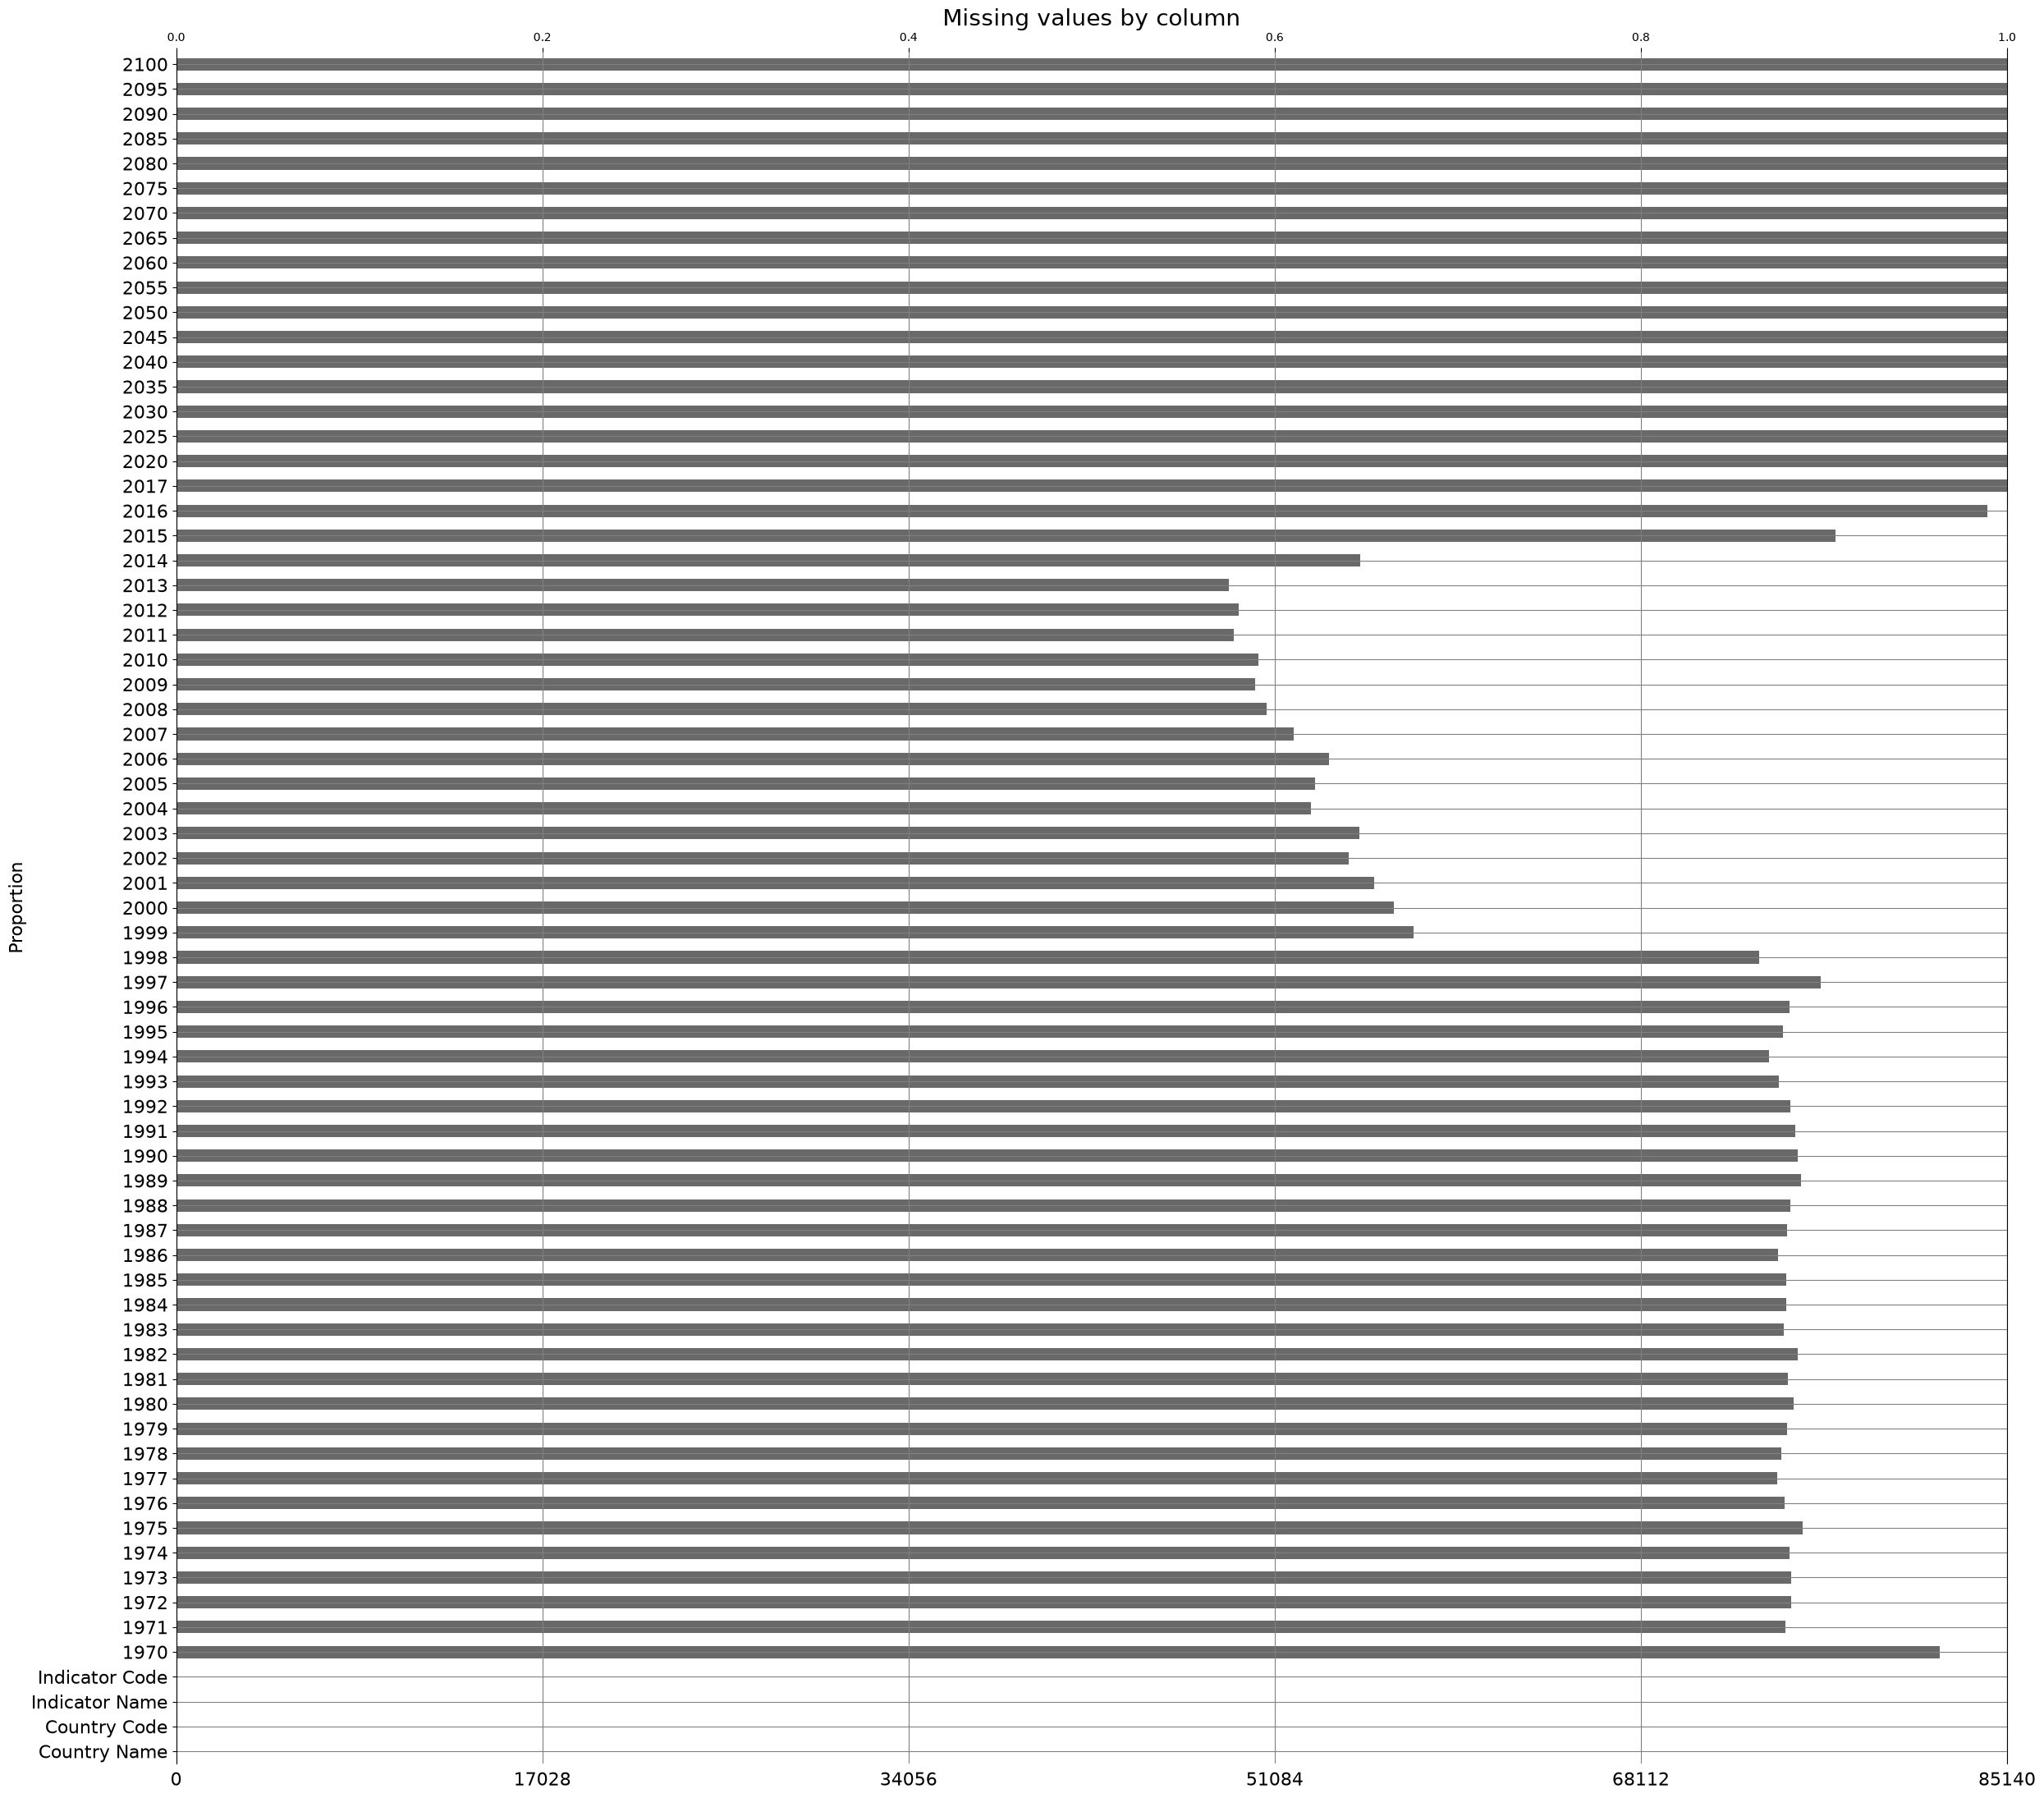

In [52]:
prop_missing = compute_and_plot_missing_values(data_clean_indicator)

A partir de 2017, les années n'ont plus aucune valeur. Nous les supprimons donc : 

In [53]:
columns_to_delete = get_columns_to_delete(prop_missing, 90)

data_clean_indicator.drop(columns = columns_to_delete, inplace = True)

Nous allons à présent calculer la proportion de valeurs manquantes : 

- Par année.
- Par indicateur.

Et comptabiliser le nombre de pays répondant par indicateur et par année.

Pour cela on peut faire appel à la méthode pd.DataFrame.count().

In [54]:
prop_colonne, prop_idx, nbr_val_df = compute_prop_values(data_clean_indicator)

In [55]:
display(prop_colonne)

1971    12.108292
1972    11.804087
1973    11.777073
1974    11.861640
1975    11.147522
1976    12.154099
1977    12.539347
1978    12.339676
1979    12.004933
1980    11.644350
1981    11.968522
1982    11.411792
1983    12.194033
1984    12.050740
1985    12.057787
1986    12.494715
1987    12.001409
1988    11.835800
1989    11.233263
1990    11.441156
1991    11.583275
1992    11.821705
1993    12.461828
1994    13.000940
1995    12.251586
1996    11.883956
1997    10.193798
1998    13.540052
1999    32.394879
2000    33.511863
2001    34.566596
2002    35.978389
2003    35.372328
2004    37.999765
2005    37.807141
2006    37.014329
2007    38.971106
2008    40.440451
2009    41.067653
2010    40.876204
2011    42.237491
2012    41.981442
2013    42.511158
2014    35.324172
dtype: float64

In [56]:
prop_idx.head()

91625    10.416667
91626    10.416667
91627    10.416667
91628    10.416667
91633     4.166667
dtype: float64

In [57]:
nbr_val_df.head(30)

,Country Name,Country Code,Indicator Code,1971,1972,1973,1974,1975,1976,1977,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
Indicator Name,,,,,,,,,,,,,,,,,,,,,
Theoretical duration of secondary education (years),198,198,198,198,198,198,198,198,198,198,...,198,198,198,198,198,198,197,197,198,198
Official entrance age to lower secondary education (years),198,198,198,198,198,198,198,198,198,198,...,198,198,198,198,198,198,197,197,198,198
Theoretical duration of upper secondary education (years),198,198,198,198,198,198,198,198,198,198,...,198,198,198,198,198,198,197,197,198,198
"Enrolment in secondary general, both sexes (number)",165,165,165,139,142,141,140,134,145,143,...,143,137,143,141,142,135,137,138,131,128
"Enrolment in secondary general, female (number)",147,147,147,118,123,122,122,117,122,124,...,126,124,125,123,125,120,124,126,117,116
Percentage of students in secondary general education who are female (%),142,142,142,113,117,117,117,112,117,119,...,126,124,125,123,125,120,124,126,117,116
"Enrolment in secondary education, both sexes (number)",137,137,137,119,116,116,109,110,116,111,...,116,115,118,115,115,115,117,111,106,101
"Enrolment in secondary vocational, both sexes (number)",133,133,133,115,116,115,109,110,115,114,...,102,98,100,96,98,98,99,100,95,90
"Gross enrolment ratio, secondary, both sexes (%)",133,133,133,115,113,112,105,106,112,108,...,115,114,116,113,112,113,114,108,104,100


Sur les 40 indicateurs les plus renseignés, les suivants ont été choisi pour leur pertinence :

- School life expectancy, secondary, both sexes (years)
- School life expectancy, tertiary, both sexes (years)
- Gross enrolment ratio, secondary, both sexes (%)
- Enrolment in secondary education, both sexes (number)
- Enrolment in tertiary education, all programmes, both sexes (number)
- Gross enrolment ratio, tertiary, both sexes (%)
- Enrolment in tertiary education per 100,000 inhabitants, both sexes
- Percentage of students in secondary education enrolled in vocational programmes, both sexes (%)
- Enrolment in secondary general, both sexes (number)
- Percentage of students in secondary education enrolled in general programmes, both sexes (%)
- Enrolment in secondary vocational, both sexes (number)
- Graduates from tertiary education, both sexes (number)

## Création d'un pivot


Avec les indicateurs identifiés, on filtre notre dataframe pour ne garder que ceux-ci.

In [58]:
indicator_list = [
    "School life expectancy, secondary, both sexes (years)",
    "School life expectancy, tertiary, both sexes (years)",
    "Gross enrolment ratio, secondary, both sexes (%)",
    "Enrolment in secondary education, both sexes (number)",
    "Enrolment in tertiary education, all programmes, both sexes (number)",
    "Gross enrolment ratio, tertiary, both sexes (%)",
    "Enrolment in tertiary education per 100,000 inhabitants, both sexes",
    "Percentage of students in secondary education enrolled in vocational programmes, both sexes (%)",
    "Enrolment in secondary general, both sexes (number)",
    "Percentage of students in secondary education enrolled in general programmes, both sexes (%)",
    "Enrolment in secondary vocational, both sexes (number)",
    "Graduates from tertiary education, both sexes (number)"
]


interesting_indicators = data_clean_indicator[data_clean_indicator["Indicator Name"].isin(indicator_list)]
interesting_indicators

,Country Name,Country Code,Indicator Name,Indicator Code,1971,1972,1973,1974,1975,1976,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
92816,Afghanistan,AFG,"Enrolment in secondary education, both sexes (...",SE.SEC.ENRL,134069.000000,153060.000000,165346.000000,172797.000000,185723.000000,204889.000000,...,651453.0,1006841.0,1035782.0,1425009.0,1.716190e+06,2.044157e+06,2.208963e+06,2.415884e+06,2.538420e+06,2.602734e+06
92822,Afghanistan,AFG,"Enrolment in secondary general, both sexes (nu...",SE.SEC.ENRL.GC,127162.000000,146988.000000,159464.000000,167397.000000,179763.000000,196991.000000,...,642442.0,NaN,1028382.0,1415293.0,1.693479e+06,2.032719e+06,2.190878e+06,2.392465e+06,2.508900e+06,2.577715e+06
92824,Afghanistan,AFG,"Enrolment in secondary vocational, both sexes ...",SE.SEC.ENRL.VO,6907.000000,6072.000000,5882.000000,5400.000000,5960.000000,7898.000000,...,9011.0,NaN,7400.0,9716.0,2.271100e+04,NaN,1.808500e+04,2.341900e+04,2.952000e+04,2.501900e+04
92826,Afghanistan,AFG,"Enrolment in tertiary education per 100,000 in...",UIS.TE_100000.56,82.615021,83.968330,95.756844,89.151741,97.596024,111.012680,...,NaN,NaN,NaN,NaN,3.498511e+02,NaN,3.384478e+02,NaN,NaN,8.311562e+02
92829,Afghanistan,AFG,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,9409.000000,9817.000000,11487.000000,10956.000000,12256.000000,14214.000000,...,NaN,NaN,NaN,NaN,9.518500e+04,NaN,9.750400e+04,NaN,NaN,2.628740e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884604,Zimbabwe,ZWE,"Gross enrolment ratio, tertiary, both sexes (%)",SE.TER.ENRR,1.718440,1.668860,1.673130,1.548440,1.584170,1.613280,...,NaN,NaN,NaN,NaN,NaN,5.905600e+00,5.823760e+00,5.868670e+00,5.871750e+00,NaN
885301,Zimbabwe,ZWE,Percentage of students in secondary education ...,UIS.GTVP.23.GPV,98.366592,98.289009,98.374420,98.305389,98.125847,97.988312,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+02,1.000000e+02,NaN
885302,Zimbabwe,ZWE,Percentage of students in secondary education ...,SE.SEC.ENRL.VO.ZS,1.633410,1.710990,1.625580,1.694610,1.874150,2.011690,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886200,Zimbabwe,ZWE,"School life expectancy, secondary, both sexes ...",UIS.SLE.23,0.454080,0.489550,0.502580,0.505350,0.521090,0.524180,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.804430e+00,2.858720e+00,NaN


A partir de ces données, on va consolidez nos résultats dans un dataframe regroupant les pays en index et les indicateurs en colonnes.

Pour cela, plusieurs étapes : 

**1.** Fondre les années en une seule colonne.
Explication : Si l'on garde l'architecture actuelle, alors le pivot_table va renvoyer tous les indicateurs ***par année***. Or, nous voulons une aggrégation des années pour avoir une vue sur les indicateurs de façon globale.

Solution : On utilise la méthode .melt() de Pandas. Elle permet de distribuer un attribut le long d'une colonne. De cette façon, nous aurons sur une entrée un nom de pays, un indicateur, une année, une valeur.

**2** Utiliser le nouveau dataframe pour faire un pivot, en choisissant une fonction d'aggrégation.

Commençons par l'étape 1  :

In [59]:
# Sélection des années
year_cols = list(interesting_indicators.select_dtypes("float64").columns)

#Distribution des années le long de Country Name et Indicator Name.
#"Year" stocke les années, et "Value" stocke la valeur associée à l'année, le pays et l'indicateur
df_long = interesting_indicators.melt(
    id_vars=["Country Name", "Indicator Name"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value")

df_long

,Country Name,Indicator Name,Year,Value
0,Afghanistan,"Enrolment in secondary education, both sexes (...",1971,134069.000000
1,Afghanistan,"Enrolment in secondary general, both sexes (nu...",1971,127162.000000
2,Afghanistan,"Enrolment in secondary vocational, both sexes ...",1971,6907.000000
3,Afghanistan,"Enrolment in tertiary education per 100,000 in...",1971,82.615021
4,Afghanistan,"Enrolment in tertiary education, all programme...",1971,9409.000000
...,...,...,...,...
113515,Zimbabwe,"Gross enrolment ratio, tertiary, both sexes (%)",2014,NaN
113516,Zimbabwe,Percentage of students in secondary education ...,2014,NaN
113517,Zimbabwe,Percentage of students in secondary education ...,2014,NaN
113518,Zimbabwe,"School life expectancy, secondary, both sexes ...",2014,NaN


Avec ce nouveau dataframe, on peut en tirer un df aggrégé de la forme voulue. 

In [60]:
results_mean = pd.pivot_table(
    df_long,
    values = "Value",
    index = "Country Name",
    columns = "Indicator Name"
)
results_mean

Indicator Name,"Enrolment in secondary education, both sexes (number)","Enrolment in secondary general, both sexes (number)","Enrolment in secondary vocational, both sexes (number)","Enrolment in tertiary education per 100,000 inhabitants, both sexes","Enrolment in tertiary education, all programmes, both sexes (number)","Graduates from tertiary education, both sexes (number)","Gross enrolment ratio, secondary, both sexes (%)","Gross enrolment ratio, tertiary, both sexes (%)","Percentage of students in secondary education enrolled in general programmes, both sexes (%)","Percentage of students in secondary education enrolled in vocational programmes, both sexes (%)","School life expectancy, secondary, both sexes (years)","School life expectancy, tertiary, both sexes (years)"
Country Name,,,,,,,,,,,,
Afghanistan,7.087979e+05,6.833864e+05,7809.666667,193.228956,40088.888889,4883.875000,22.988050,2.116083,98.413641,1.618446,1.383445,0.105804
Albania,3.974821e+05,3.322949e+05,68176.000000,1822.244792,53885.305556,8368.068966,82.027761,19.707005,84.622410,16.022224,6.414318,1.028078
Algeria,2.179376e+06,2.167955e+06,161337.375000,1977.490242,662079.782609,64976.185185,51.979167,18.872682,92.418723,7.581278,3.363130,0.943634
American Samoa,2.943667e+03,3.037231e+03,68.038462,NaN,872.800000,111.333333,NaN,NaN,NaN,NaN,NaN,NaN
Andorra,2.918350e+03,2.733600e+03,184.750000,NaN,403.666667,55.111111,24.387873,NaN,95.205367,4.794633,1.707150,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
Virgin Islands (U.S.),1.174435e+04,1.174435e+04,0.000000,NaN,2217.157895,179.076923,NaN,NaN,NaN,NaN,NaN,NaN
West Bank and Gaza,5.932488e+05,5.890813e+05,4167.526316,3544.200986,134582.105263,21577.928571,82.451616,36.198249,99.320593,0.679407,6.561816,2.011239
"Yemen, Rep.",1.469243e+06,1.458700e+06,16926.666667,949.079205,197306.923077,20803.333333,45.326966,9.392854,99.275111,0.713396,2.749217,0.469642


In [61]:
prop_par_attribut = results_mean.count(axis=0)/results_mean.shape[0] *100
prop_par_attribut

Indicator Name
Enrolment in secondary education, both sexes (number)                                              100.000000
Enrolment in secondary general, both sexes (number)                                                100.000000
Enrolment in secondary vocational, both sexes (number)                                              98.564593
Enrolment in tertiary education per 100,000 inhabitants, both sexes                                 91.866029
Enrolment in tertiary education, all programmes, both sexes (number)                                97.129187
Graduates from tertiary education, both sexes (number)                                              92.822967
Gross enrolment ratio, secondary, both sexes (%)                                                    94.258373
Gross enrolment ratio, tertiary, both sexes (%)                                                     92.344498
Percentage of students in secondary education enrolled in general programmes, both sexes (%)        96.65

In [62]:
prop_par_pays =  results_mean.count(axis=1)/results_mean.shape[1] *100
prop_par_pays.loc[prop_par_pays<50].sort_values(ascending=True)

Country Name
South Sudan              25.000000
American Samoa           41.666667
French Polynesia         41.666667
Faroe Islands            41.666667
Guam                     41.666667
Monaco                   41.666667
New Caledonia            41.666667
Virgin Islands (U.S.)    41.666667
dtype: float64

**CONCLUSION :** Dans notre DataFrame consolidé, la totalité des indicateurs ont plus de 90% de remplissage, et seulement 8 pays sur 209 ont moins de la moitié de valeurs existantes. 
A mon sens, la combinaison d'indicateurs et d'années choisis ont permis de consolider au maximum notre tableau.

## Comparaison de fonctions d'aggrégations

Cela dit, un point mérite discussion. 
La fonction utilisée pour l'aggrégation est la moyenne arithmétique. Elle comporte à mes yeux un problème principal.
Elle traite toutes les valeurs à parts égales, et est de ce fait très sensible aux valeurs extrèmes.
Dans notre cas, la valeur d'un indicateur relevée en 1970 aura le même poids que celle relevée en 2015. 
Du points de vue de notre problématique, nous sommes plus intéressés par les valeurs récentes. Elles sont en effet meilleure qualité pour l'appréciation de quel pays viser pour l'implémentation.

De ce fait, il m'est préférable de faire une aggrégation en donnant plus de poids aux valeurs récentes. Nous gardons ainsi les informations passées, mais privilégions celles qui se rapprochent du présent.

Pour cela, nous pouvons remplacer la moyenne arithmétique par une moyenne pondérée. Le calcul des poids a été arbitrairement fait en utilisant une loi exponentielle de la forme  \$ weight = \lambda^{(année_{max} - année)}$, avec : 

- \$\lambda$ un réel,
  
- \$annee_{max}$, la dernière année possèdant une valeur,
  
- \$année$ l'année étudiée.

De cette façon, la valeur la plus récente aura un poids proche de un, et les plus anciennes proche de 0. Le coefficient \$\lambda$ contrôle la vitesse avec laquelle les anciennes années sont impactées. Pour le choisir, je regarde l'évolution de la fonction pour de multiples \$\lambda$


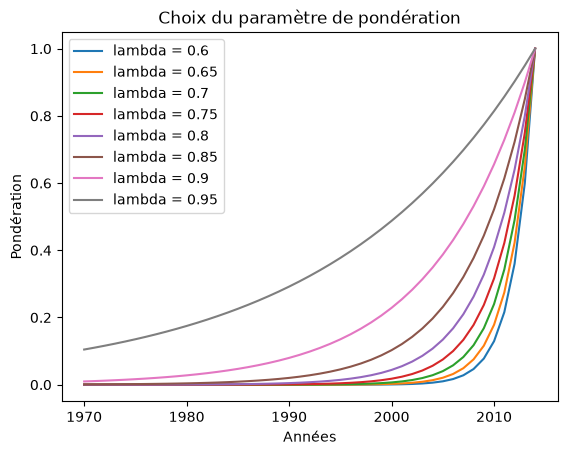

In [63]:
lambdas = np.arange(0.6, 1, 0.05 )

x = np.arange(1970, 2015, 1)

for lambda_ in lambdas :
    y = lambda_**(max(x) - x)
    plt.plot(x,y, label = f"lambda = {round(lambda_,2)}")
plt.xlabel("Années")
plt.ylabel("Pondération")
plt.title("Choix du paramètre de pondération")
plt.legend()
plt.show()


Dans un contexte où il faut préserver les informations des années passées, tout en "avantageant" les valeurs actuelles, le \$\lambda$ choisie est 0.95


In [64]:
# Suppression des valeurs nulles dans le DataFrame
df_long = df_long.dropna(subset=["Value"])

# Calcul des dernières années renseignées
df_long["Year"] = df_long["Year"].astype(int)
df_long["LastYear"] = (
    df_long
    .groupby(["Country Name", "Indicator Name"])["Year"]
    .transform("max")
)
# Calcul des poids par pays, par indicateur, par année
lambda_ = 0.95
df_long["Weight"] = lambda_ ** (df_long["LastYear"] - df_long["Year"])
df_long.head()


,Country Name,Indicator Name,Year,Value,LastYear,Weight
0,Afghanistan,"Enrolment in secondary education, both sexes (...",1971,134069.000000,2014,0.110183
1,Afghanistan,"Enrolment in secondary general, both sexes (nu...",1971,127162.000000,2014,0.110183
2,Afghanistan,"Enrolment in secondary vocational, both sexes ...",1971,6907.000000,2014,0.110183
3,Afghanistan,"Enrolment in tertiary education per 100,000 in...",1971,82.615021,2014,0.110183
4,Afghanistan,"Enrolment in tertiary education, all programme...",1971,9409.000000,2014,0.110183


Plusieurs choses sont à remarquer dans le code précédent : 

- On supprime les valeurs nulles pour ne pas biaiser le calcul des poids. Dans le cas où on garde ces valeurs nulles, un poids pourrait y être affecté, ce qui fausserait le résultat.
- On calcule un nouvel attribut "Last Year", qui est la dernière année renseignée par pays, par indicateur. Pour cela on groupe par pays et indicateur et on sélectionne les années. On utilise la méthode .transform() qui appelle une fonction sur le dataframe, et renvoie une Series/DataFrame dans le même axe (index  par défaut, ou col) que le DataFrame utilisé. Dans notre cas, on renvoie l'année max.
- On calcule ensuite le poids via la fonction indiquée plus haut.

Il ne reste plus qu'à calculer la moyenne pondérée et d'aggréger notre DataFrame en table.

In [65]:
# Calcul de la moyenne pondérée du groupe, soit un pays, un indicateur

#Calcul de la table
results_weighted = (
    df_long
    .groupby(["Country Name", "Indicator Name"])
    .apply(weighted_average)
    .unstack("Indicator Name")
)

results_weighted.head()

Indicator Name,"Enrolment in secondary education, both sexes (number)","Enrolment in secondary general, both sexes (number)","Enrolment in secondary vocational, both sexes (number)","Enrolment in tertiary education per 100,000 inhabitants, both sexes","Enrolment in tertiary education, all programmes, both sexes (number)","Graduates from tertiary education, both sexes (number)","Gross enrolment ratio, secondary, both sexes (%)","Gross enrolment ratio, tertiary, both sexes (%)","Percentage of students in secondary education enrolled in general programmes, both sexes (%)","Percentage of students in secondary education enrolled in vocational programmes, both sexes (%)","School life expectancy, secondary, both sexes (years)","School life expectancy, tertiary, both sexes (years)"
Country Name,,,,,,,,,,,,
Afghanistan,1.190270e+06,1.157704e+06,11197.860850,307.713917,81726.754237,8909.343270,32.558617,3.320036,98.990564,1.038203,1.961596,0.166002
Albania,3.837878e+05,3.385841e+05,45142.659065,2581.197245,76241.009765,11715.532756,82.496253,27.714694,89.155510,10.976275,6.309669,1.469818
Algeria,2.930327e+06,2.933838e+06,236923.443795,2344.618406,815908.197930,129216.235097,65.394757,22.469233,92.278099,7.721902,4.231710,1.123462
American Samoa,3.066343e+03,3.191634e+03,95.637820,NaN,986.073190,109.587586,NaN,NaN,NaN,NaN,NaN,NaN
Andorra,3.667293e+03,3.399592e+03,267.700926,NaN,423.077138,58.870555,26.877119,NaN,93.173565,6.826435,1.881397,NaN


Le choix de passer par un .groupby().apply().unstack() a été fait pour éviter de passer par .pivot_table()

Bien que la structure du résultat soit identique au final, la méthode pivot_table() aurait nécessité des opérations supplémentaires.
En effet, le processus utilisé ici groupe le DataFrame par pays et par indicateur (groupby), calcule la moyenne pondérée (apply), et pivote la colonne des indicateurs (unstack).

Pour obtenir la même chose avec pivot_table, il aurait fallu : 

- Calculer les valeurs pondérées (value*weight)
- Effectuer le pivot avec DEUX colonnes : valeurs pondérées et poids, en utilisant la fonction d'aggrégation sum().
- Diviser la somme des valeurs pondérées par la somme des poids.

Nous aurions eu : 

``` Python
df_long["WeightedValue"] = df_long["Value"] * df_long["Weight"]

pivot = df_long.pivot_table(
    index="Country Name",
    columns="Indicator Name",
    values=["WeightedValue", "Weight"],
    aggfunc="sum"
)
results_weight_pivot = pivot["WeightedValue"]/pivot["Weight"]
```
Donc une colonne (ou section) WeightedValue avec tous les indicateurs, et une autre Weight avec tous les indicateurs de nouveau.
Et enfin la division de chaque colonne pour avoir la moyenne pondérée.
Le résultat aurait été identique, en témoigne la cellule de code just en dessous

In [66]:
df_long["WeightedValue"] = df_long["Value"] * df_long["Weight"]

pivot = df_long.pivot_table(
    index="Country Name",
    columns="Indicator Name",
    values=["WeightedValue", "Weight"],
    aggfunc="sum"
)
results_weight_pivot = pivot["WeightedValue"]/pivot["Weight"]
results_weight_pivot.head(1)

Indicator Name,"Enrolment in secondary education, both sexes (number)","Enrolment in secondary general, both sexes (number)","Enrolment in secondary vocational, both sexes (number)","Enrolment in tertiary education per 100,000 inhabitants, both sexes","Enrolment in tertiary education, all programmes, both sexes (number)","Graduates from tertiary education, both sexes (number)","Gross enrolment ratio, secondary, both sexes (%)","Gross enrolment ratio, tertiary, both sexes (%)","Percentage of students in secondary education enrolled in general programmes, both sexes (%)","Percentage of students in secondary education enrolled in vocational programmes, both sexes (%)","School life expectancy, secondary, both sexes (years)","School life expectancy, tertiary, both sexes (years)"
Country Name,,,,,,,,,,,,
Afghanistan,1.190270e+06,1.157704e+06,11197.86085,307.713917,81726.754237,8909.34327,32.558617,3.320036,98.990564,1.038203,1.961596,0.166002


Si l'on se base sur l'hypothèse que le nombre de lycéens et d'étudiants augmente dans le temps, alors on devrait trouver des valeurs pondérées supérieures dans la table pondérée.
On vérifie cela avec la cellulle suivante.

In [67]:
row, col = results_weighted.shape

print(f"Le pourcentage de valeurs supérieures dans la table pondérée par rapport à la table de base est de :", 
        f"{round((results_mean < results_weighted).sum().sum() / (row*col) * 100,1)}%")

Le pourcentage de valeurs supérieures dans la table pondérée par rapport à la table de base est de : 77.3%


**NOTE :** Un % inférieur à 100% peut tout simplement indiquer que dans certains pays, certains indicateurs ont diminué dans le temps. L'hypothèse faite précédemment semble toutefois tenir la route au vu du % de valeurs supérieures.

**CONCLUSION :** Par la suite, on préferera utiliser la tableau consolidé via la moyenne pondérée. 

# EXERCICE 3

## Identification des indicateurs indépendants

In [68]:
corr_pearson = results_weighted.corr(method = "pearson", min_periods = 1, numeric_only = True).abs()
mask = np.triu(corr_pearson)

In [69]:
corr_spearman = results_weighted.corr(method = "spearman", min_periods = 1, numeric_only = True).abs()

/tmp/ipykernel_209864/105992368.py:2: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


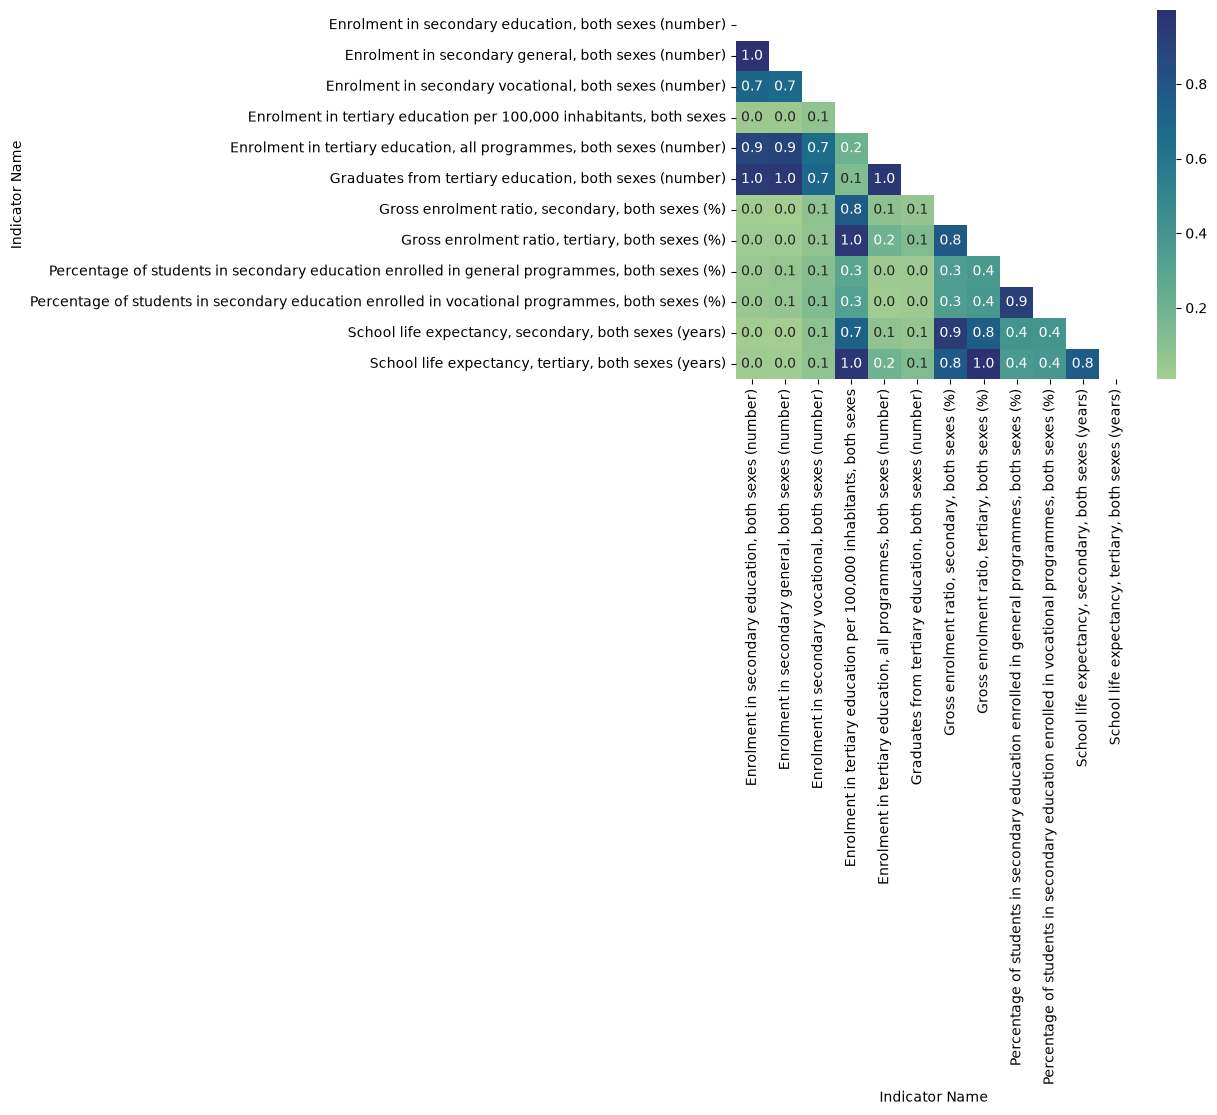

In [70]:
sns.heatmap(corr_pearson, mask = mask, annot=True, fmt = "0.1f" , cmap = "crest")
plt.tight_layout()

<Axes: xlabel='Indicator Name', ylabel='Indicator Name'>

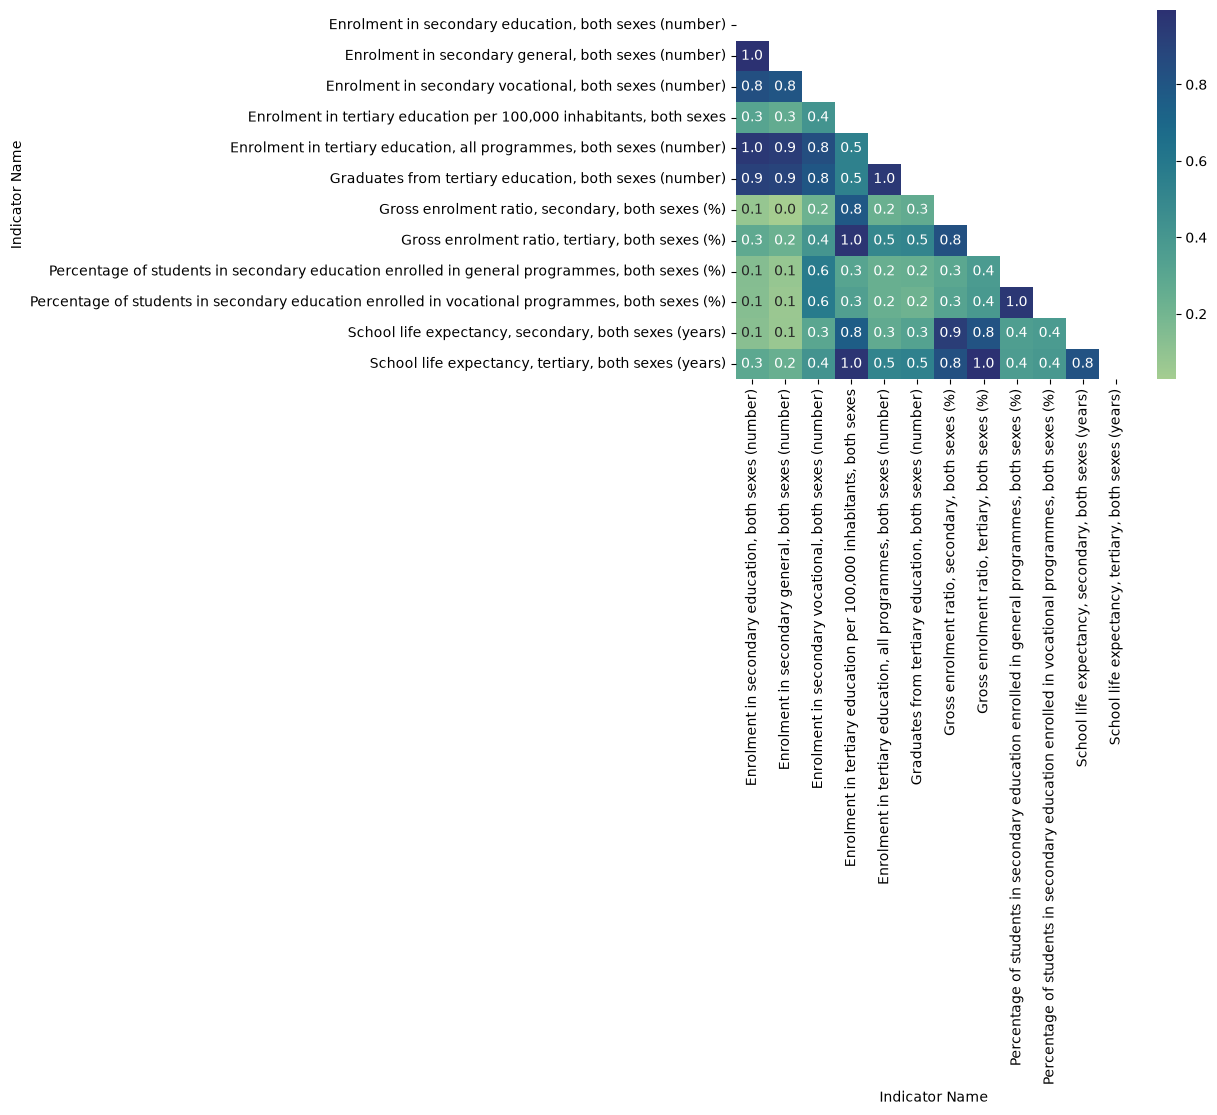

In [71]:
sns.heatmap(corr_spearman, mask = mask, annot=True, fmt = "0.1f" , cmap = "crest")

**NOTES SUR LES COEFFICIENTS :** Les coefficients calculés sont ceux de Pearson et Spearman. Ils se calculent selon : 

- Pearson : \$ r = \frac{Cov(X,Y)}{\sigma_x\sigma_y} $.
  
- Spearman : \$ \rho = \frac{Cov(rg_X, rg_Y)}{\sigma_{rg_x}\sigma_{rg_y}}$.

Bien que leurs formules soient similaires, Pearson se base sur les valeurs des séries X et Y, alors que Spearman se base sur le rang de ces valeurs - après tri.
De ce fait : 

- Pearson est un indicateur sur la corrélation linéaire entre les deux variables. Plus r est proche des extrèmes [-1,1], plus la relation entre ces deux variables est affine. A noter qu'un r=0 indique l'indépendance des variables.
  
- Spearman est un indicateur de la monotonie de la relation entre les deux variables. Plus \$\rho$ est proche des extrèmes [-1, 1], plus la relation est monotone décroissante (-1), croissante (1), ou non-monotone (0). MAIS elle n'indique pas la forme de la relation. En effet, le coefficient de Spearman marche pour tout type de fonction. Et sera forcément supérieur au coefficient de Pearson si la fonction est non-affine.

*En conséquence,* deux variables ayant une relation non-affine mais monotone croissante pourront simultanément avoir un coefficient de Pearson bas (<0.5) mais un haut coefficient de Spearman. De plus, \$\rho$ est robuste aux valeurs extrèmes, à l'inverse de r.

De ce fait, je préfère utiliser la méthode Spearman. Une autre manière plus claire de regarder les indicateurs fortement corrélés est de regarder les pairs satisfaisant un coefficient > 0.8. De cette manière je peux choisir lesquels garder en cas de forte corrélation.


In [72]:
corr = results_weighted.corr(method = "spearman")

threshold = 0.8

high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=abs, ascending=False)
)

high_corr[high_corr.abs() > threshold]

Indicator Name                                                                                Indicator Name                                                                                 
Gross enrolment ratio, tertiary, both sexes (%)                                               School life expectancy, tertiary, both sexes (years)                                               0.994942
Enrolment in secondary education, both sexes (number)                                         Enrolment in secondary general, both sexes (number)                                                0.991089
Enrolment in tertiary education per 100,000 inhabitants, both sexes                           School life expectancy, tertiary, both sexes (years)                                               0.979492
                                                                                              Gross enrolment ratio, tertiary, both sexes (%)                                                    0.973134
Pe

De ce résultat, je garde trois indicateurs : 

- "Enrolment in secondary education, both sexes (number)",
- "Gross enrolment ratio, secondary, both sexes (%)",
- "Enrolment in tertiary education per 100,000 inhabitants, both sexes".

Principalement car le nombre d'inscrit en secondaire est lié au nombre d'inscrit à l'université, mais aussi au nombre d'inscrit dans les programmes techniques ou généraux. Le ratio d'inscrit au secondaire est très corrélé avec celui des inscrits à l'université, et permet d'éliminer d'autres indicateurs comme le nombre d'années moyennes passés au lycée/ à l'université. Et enfin, le ratio d'inscrit à l'université par X habitants permet de retenir une information sur l'université, et est faiblement corrélé à tous les autres indicateurs.

In [73]:
independant_indicators = [
    "Gross enrolment ratio, secondary, both sexes (%)",
    "Enrolment in secondary education, both sexes (number)",
    "Enrolment in tertiary education per 100,000 inhabitants, both sexes",
]
independant_results = results_weighted[independant_indicators]
independant_results

Indicator Name,"Gross enrolment ratio, secondary, both sexes (%)","Enrolment in secondary education, both sexes (number)","Enrolment in tertiary education per 100,000 inhabitants, both sexes"
Country Name,,,
Afghanistan,32.558617,1.190270e+06,307.713917
Albania,82.496253,3.837878e+05,2581.197245
Algeria,65.394757,2.930327e+06,2344.618406
American Samoa,NaN,3.066343e+03,NaN
Andorra,26.877119,3.667293e+03,NaN
...,...,...,...
Virgin Islands (U.S.),NaN,1.224611e+04,NaN
West Bank and Gaza,83.513275,6.267769e+05,3869.979952
"Yemen, Rep.",45.471432,1.513711e+06,999.863772


## Analyse descriptives des indicateurs restants

In [74]:
independant_results.describe()

Indicator Name,"Gross enrolment ratio, secondary, both sexes (%)","Enrolment in secondary education, both sexes (number)","Enrolment in tertiary education per 100,000 inhabitants, both sexes"
count,197.000000,2.090000e+02,192.000000
mean,68.844464,2.179518e+06,2011.704671
std,30.531278,8.369229e+06,1467.719903
min,7.866330,9.873115e+02,47.468087
25%,42.858599,5.725324e+04,597.566241
50%,77.712644,3.622344e+05,1882.241836
75%,93.331348,1.200049e+06,3197.867874
max,140.958173,8.375385e+07,5760.899811


Etant donné que les valeurs moyennes, minimales et maximales sont très différentes entre les indicateurs, chacun aura son propre graphe. 
Commençons par les boîtes à moustache pour mieux visualiser.

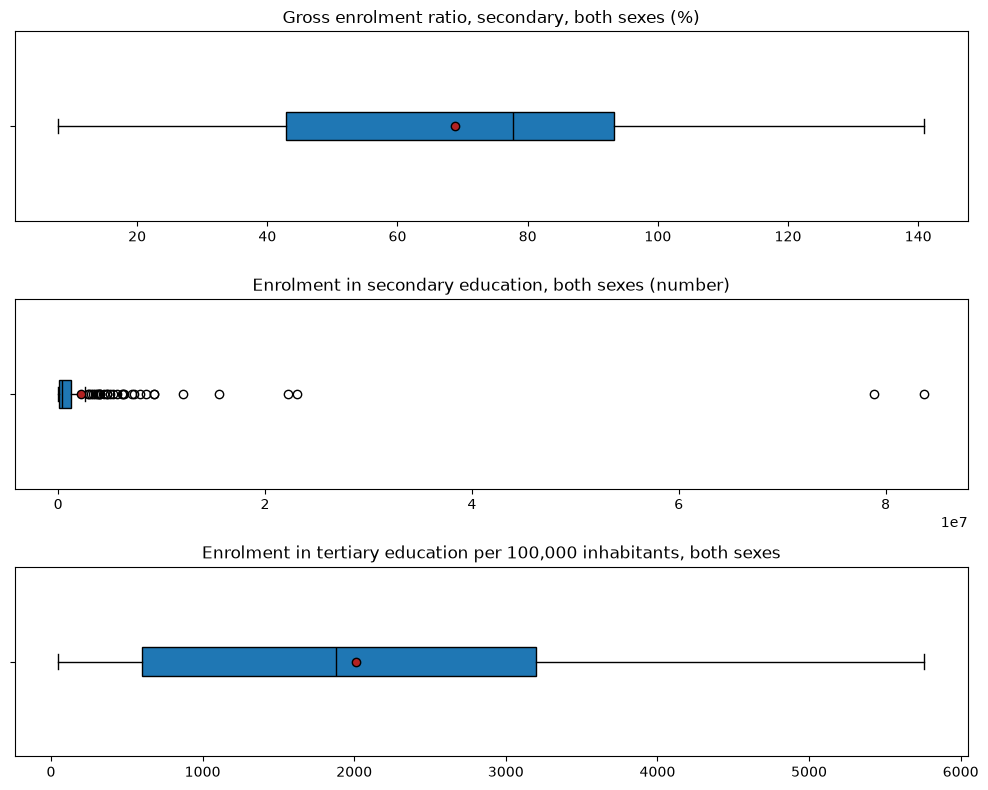

In [75]:
draw_boxplot(independant_results)

Allons y indicateur par indicateur. 

- **Gross enrolment ratio :** ~5% de valeurs nulles. La moyenne est légèrement à gauche de la médiane, ce qui indiquerait une distribution légèrement asymétrique avec une queue plus prononcée vers la gauche. Nous n'avons pas de valeurs anormales, mais Q2 comprend une large étendue de valeur. 

- **Enrolment secondary education :** Pas de valeurs manquantes. La moyenne est dans Q4, ce qui indique une distribution très asymétrique vers la droite. Beaucoup de valeurs abherantes mais pas anormales. En réalité la boîte à moustache n'est pas adapté pour cet indicateur. Il y a beaucoup de différences entre pays, comme l'indique l'écart type.

- **Enrolment in tertiary education :** ~10% de valeurs manquantes. La distribution est légèrement asymétrique vers la droite. Les 25% de Q4 ont une étendue assez large, avec une large différence entre la valeur minimale et la valeur maximale. L'écart type est également assez grand, ce qui corrèle bien avec les observations.


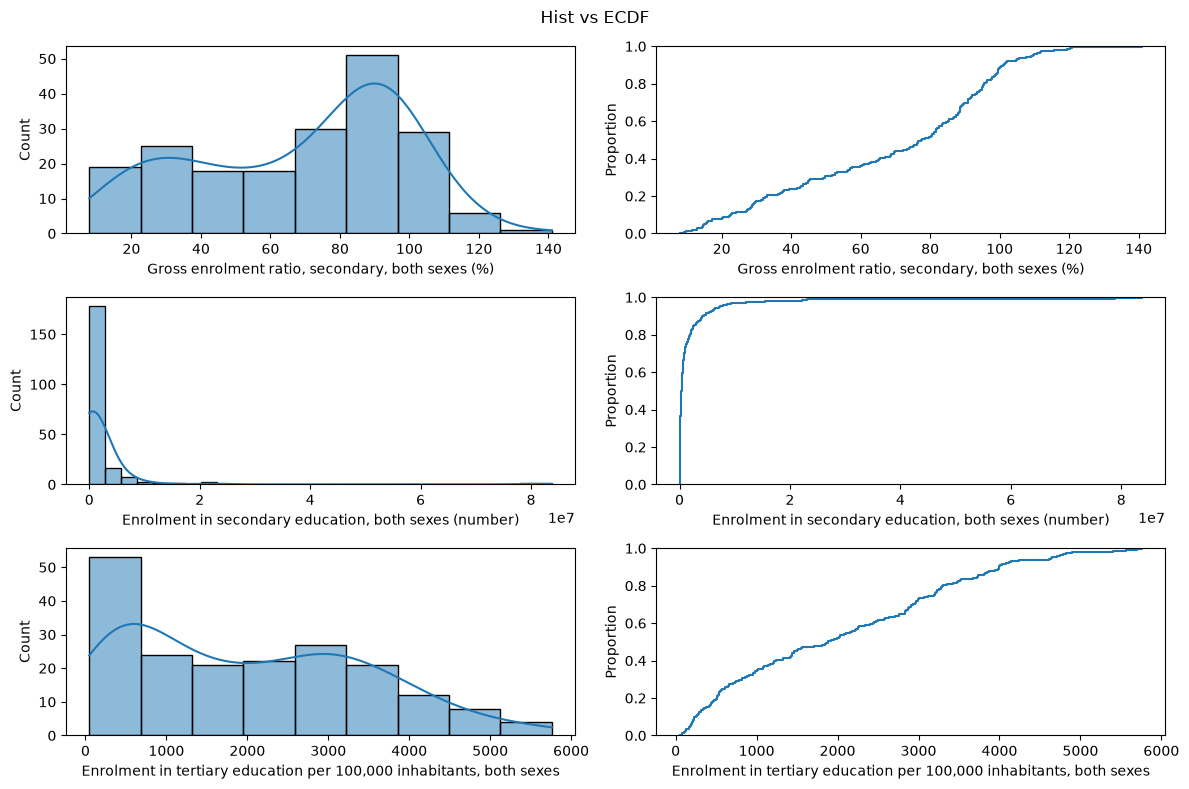

In [76]:
draw_displot(independant_results)

Nous pouvons confirmer/infirmer plusieurs choses ici concernant les trois indicateurs.

- **Gross enrolment ratio :** Distribution bimodale, avec le mode principale autour des 90%. La distribution empirique des fréquences cumulées montre bien le mode principale. Globalement pas de changement avec la dernière analyse.

- **Enrolment secondary education :** La distribution est très centrée pour des valeurs inférieures à 1.10^7. Selon Q4 précédemment, environ 75% des valeurs sont comprises avec 1.10^6, ce qui explique ce mode initial. L'ecdf montre également ce phénomène, avec ~85% des valeurs atteintes à 1.10^7. Les 15% restants sont étendues sur une large zone allant jusqu'à 8.10^7. Le même phénomène qu'avec la boîte à moustache est observé, mais plus visible.

- **Enrolment in tertiary education :** Distribution légèrement bimodale avec le mode principale autour des 800. Répartition relativement homogène. Même analyse qu'avec la boîte à moustache.

*Remarque :* Les différences entre pays pour un indicateur sont très marquées lorsqu'elles ne sont pas normalisées. En l'occurence, il est difficile de tirer une information de juste un nombre d'inscrit, vu que celui-ci pourrait dépendre, non pas exclusivement, du nombre d'habitants dans un pays.  


Il ne nous reste plus qu'à identifier les pays qui nous intéressent le plus au vu de notre problématique. Nous allons d'abord rechercher une éventuelle correspondance de pays ayant les meilleurs valeurs pour chaque indicateur.

In [77]:
top_ratio_sec = independant_results.sort_values(by="Gross enrolment ratio, secondary, both sexes (%)", ascending=False)[:5]
top_ratio_sec

Indicator Name,"Gross enrolment ratio, secondary, both sexes (%)","Enrolment in secondary education, both sexes (number)","Enrolment in tertiary education per 100,000 inhabitants, both sexes"
Country Name,,,
Australia,140.958173,2.348975e+06,4649.431117
Netherlands,120.680836,1.448774e+06,3355.387040
Belgium,120.366929,9.204852e+05,3485.410629
Denmark,119.304208,4.806875e+05,3738.035669
Finland,115.653663,4.571908e+05,4714.616462


In [78]:
top_enrolment = independant_results.sort_values(by="Enrolment in secondary education, both sexes (number)", ascending=False)[:5]
top_enrolment

Indicator Name,"Gross enrolment ratio, secondary, both sexes (%)","Enrolment in secondary education, both sexes (number)","Enrolment in tertiary education per 100,000 inhabitants, both sexes"
Country Name,,,
India,52.561814,8.375385e+07,1168.604386
China,65.469677,7.883567e+07,1327.443602
United States,94.137489,2.307627e+07,5695.724346
Brazil,99.516905,2.221969e+07,2867.228475
Indonesia,59.825749,1.551609e+07,1503.892080


In [79]:
top_ratio_tertiary = independant_results.sort_values(by="Enrolment in tertiary education per 100,000 inhabitants, both sexes", ascending=False)[:5]
top_ratio_tertiary

Indicator Name,"Gross enrolment ratio, secondary, both sexes (%)","Enrolment in secondary education, both sexes (number)","Enrolment in tertiary education per 100,000 inhabitants, both sexes"
Country Name,,,
Puerto Rico,81.228219,2.770387e+05,5760.899811
United States,94.137489,2.307627e+07,5695.724346
Canada,101.545121,2.533320e+06,5558.141356
"Korea, Rep.",92.852815,4.001921e+06,5397.174446
Russian Federation,91.762564,1.210104e+07,4894.702094


Malheureusement, aucun des indicateurs n'a de même pays dans son top 5. Il ne nous reste plus qu'à trouver le pays faisant au mieux dans ses trois indicateurs. 

## Sélection des pays

La méthode utilisée est la suivante :

- Rechercher les pays dits "dominés". Ce sont ceux qui sont surpassés dans toutes les catégories, et qui ne nous intéressent donc pas.
- Attribuer un score à chaque pays "dominants", pour les classer et choisir les 5 premiers.

Afin de réaliser ces deux étapes, je trouve qu'il est nécessaire de normaliser nos variables, pour qu'elle soit comprise en 0 et 1.
Bien qu'il ne soit pas important dans la recherche des pays "dominés" et "dominants", il est essentiel dans l'attribution du score dans la deuxième étape.

En effet, l'attribution du score va se faire par une moyenne, pondéré ou non. Dans les deux cas, les échelles des unités sont trop disparatres pour traiter les données telles que. La variable "Enrolment in secondary education" désavantagerait trop les pays faiblements peuplés. Si l'on utilisait une moyenne pondérée, le poids associée à cette variable serait trop compliqué à estimer/traiter. 

Donc, on commence par normaliser les variables. J'ai choisi la normalisation Min-Max, qui rabat les variables entre 0 et 1 selon :
\$ \frac{x - x_{MAX}}{x_{MAX}-x_{MIN}}$ 

Cela peut se faire via une vectorisation numpy, mais également via la méthode dédiée de la bibliothèques SciKit Lean.


In [80]:
from sklearn.preprocessing import MinMaxScaler

index = independant_results.index
cols = independant_results.columns
df_copy = independant_results.copy()

scaler = MinMaxScaler()
normalized_df = pd.DataFrame(scaler.fit_transform(df_copy), index = index, columns= cols)
normalized_df

Indicator Name,"Gross enrolment ratio, secondary, both sexes (%)","Enrolment in secondary education, both sexes (number)","Enrolment in tertiary education per 100,000 inhabitants, both sexes"
Country Name,,,
Afghanistan,0.185528,0.014200,0.045550
Albania,0.560740,0.004571,0.443469
Algeria,0.432246,0.034976,0.402061
American Samoa,NaN,0.000025,NaN
Andorra,0.142840,0.000032,NaN
...,...,...,...
Virgin Islands (U.S.),NaN,0.000134,NaN
West Bank and Gaza,0.568382,0.007472,0.669040
"Yemen, Rep.",0.282550,0.018062,0.166694


Chaque variable a bien été ramené sur l'intervalle [0,1]. 
On peut regarder les dpays dominants via un graphe pour avoir une première idée.

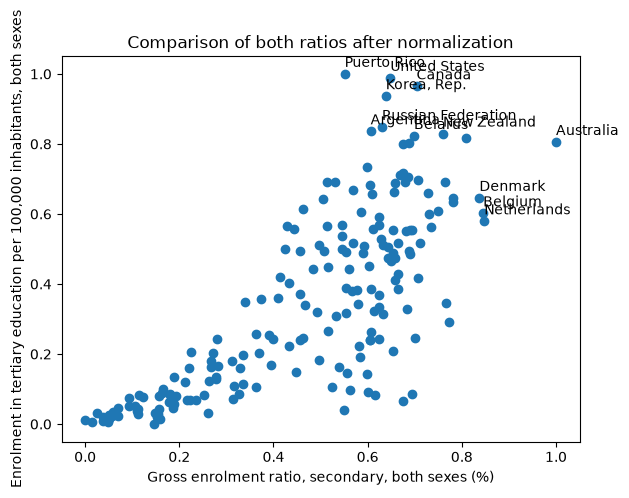

In [81]:

fig,ax = plt.subplots()

x = normalized_df["Gross enrolment ratio, secondary, both sexes (%)"]
y = normalized_df["Enrolment in tertiary education per 100,000 inhabitants, both sexes"]
countries = normalized_df.index

ax.scatter(x = x, y = y)

plt.ylabel(cols[-1])
plt.xlabel(cols[0])
plt.title("Comparison of both ratios after normalization")

for i in range(len(normalized_df)):
    if x.iloc[i] >= 0.82 or y.iloc[i] >= 0.82 : 
        plt.annotate(countries[i].strip(), (x.iloc[i], y.iloc[i] + 0.02))
    
plt.tight_layout()
plt.show()

On voit quelques pays sortir du lot et dominer le reste : l'Australie, le Canada, Puerto Rico et les Etats-Unis.

**CEPENDANT**, le graphe ne prend pas en compte toutes les variables pour des raisons de simplicité. Il nous faut donc composer avec toutes les variables pour avoir un résultat correct.

Pour cela, on va éliminer les pays dits dominés. Les critères d'évaluation sont les suivants : 

- Il existe un autre pays pour qui chacun des indicateurs est supérieur ou égal au pays concerné.
- Il existe un autre pays qui a au moins un indicateur supérieur au pays concerné.

Si un pays respecte ses deux conditions, alors il est "*dominé*" par un autre pays. Dans le cas contraire, le pays est dit "*dominant*".
Je sélectionne les pays donc les pays via ses conditions, grâce à la fonction pareto_frontier().

In [82]:
best_countries = pareto_frontier(normalized_df)
display(best_countries)

Indicator Name,"Gross enrolment ratio, secondary, both sexes (%)","Enrolment in secondary education, both sexes (number)","Enrolment in tertiary education per 100,000 inhabitants, both sexes"
Country Name,,,
Australia,1.000000,0.028035,0.805464
Brazil,0.688627,0.265289,0.493532
Canada,0.703866,0.030236,0.964512
China,0.432809,0.941278,0.224029
Finland,0.809872,0.005447,0.816873
France,0.734100,0.068483,0.561799
Germany,0.711777,0.094234,0.518429
India,0.335824,1.000000,0.196228
Japan,0.689556,0.101740,0.486727


Maintenant que j'ai la liste des pays dominants, je peux leur affecter un score. 

Ce score est une moyenne des trois variables, ce qui donne le même poids à chacune d'elle.
Néanmoins, il m'est difficile à ce stade de dire si une variable est plus importante que l'autre. J'ai donc fais le parti pri d'utiliser une moyenne pondérée à la place et de qualifier mes pays non pas par le meilleur score, mais par leur robustesse à la pondération.

Globalement, je vais calculer la moyenne de chaque pays, pour différents poids, et regarder quel est le rang atteint par ce pays à chaque fois. Les pays ayant le plus haut rang malgré les pondérations différentes seront vus comme les plus robustes, et donc les "meilleures".

In [83]:
weights_combinations = []

for w_1 in np.arange(0,1.1,0.1):
    for w_2 in np.arange(0, 1.1 - w_1, 0.1):
        w_3 = 1 - w_1 - w_2
        weights_combinations.append((w_1, w_2, w_3))

robust_countries = find_robust_countries(best_countries,
                                         weights_combinations,
                                         5)
robust_countries.head(5)

,%_top_n,rang_moyen,rang_median
Country Name,,,
United States,85.7,3.5,3.0
Australia,77.1,3.7,4.0
Canada,62.9,5.5,4.5
Finland,52.9,5.9,5.0
China,45.7,7.4,8.5
